# Heart Disease Prediction Using Machine Learning

**Module:** Machine Learning   
**Assessment Type:** Coursework   
**Chinese Name:** 王彦彬  
**Student ID:** 2023141460027  
**University:** Sichuan University  
**Lecturers:** Huiru Zheng and Jingtao Fu  
**Dataset:** UCI Cleveland Heart Disease Dataset  
**Programming Environment:** Python and Jupyter Notebook  

**Notebook URL:**  
https://github.com/B1B101/Heart_Disease_Project/blob/main/notebooks/2023141460027_%E7%8E%8B%E5%BD%A6%E5%BD%AC.ipynb
**Dataset Source URL:**  
https://archive.ics.uci.edu/dataset/45/heart%2Bdisease

# Part I: Domain Introduction and Exploratory Data Analysis

## Domain and Dataset Introduction

Heart disease is an important healthcare problem because it can affect the structure or function of the heart and may lead to serious health outcomes. Clinical assessment commonly considers several types of information, including patient demographics, symptoms, blood-pressure measurements, laboratory results and exercise-related indicators. Machine-learning methods can be used to examine relationships among these variables and investigate whether they contain sufficient information to support the identification of patients with heart disease.

This report uses exploratory data analysis to examine the distributions, data quality and relationships within a publicly available heart disease dataset. The exploratory findings are then used to define a practical classification problem for the machine-learning analysis conducted in Part II.

### Dataset Source and Size

The dataset used in this report is the Cleveland subset of the Heart Disease dataset from the UCI Machine Learning Repository (Janosi et al., 1988). The original Cleveland dataset contains 303 patient records and 14 variables. These variables consist of 13 clinical predictor variables and one target variable describing the diagnosed heart disease status.

The raw target variable originally contains values from 0 to 4. A value of 0 indicates the absence of diagnosed heart disease, while values from 1 to 4 indicate different levels of disease presence. For the analysis in this report, the target was transformed into a binary classification variable:

- **0: No heart disease**
- **1: Heart disease present**

Six records contained missing values in the `ca` or `thal` variables. After these incomplete records were removed, 297 complete patient records remained for exploratory analysis and machine-learning modelling.

### Dataset Variables

| Variable | Description | Analytical type |
|---|---|---|
| `age` | Age in years | Continuous |
| `sex` | Sex of the patient | Binary categorical |
| `cp` | Chest pain type | Categorical |
| `trestbps` | Resting blood pressure | Continuous |
| `chol` | Serum cholesterol | Continuous |
| `fbs` | Fasting blood sugar indicator | Binary categorical |
| `restecg` | Resting electrocardiographic result | Categorical |
| `thalach` | Maximum heart rate achieved | Continuous |
| `exang` | Exercise-induced angina | Binary categorical |
| `oldpeak` | ST depression induced by exercise | Continuous |
| `slope` | Slope of the peak exercise ST segment | Ordinal categorical |
| `ca` | Number of major vessels observed by fluoroscopy | Discrete numerical |
| `thal` | Thalassemia-related test result | Categorical |
| `target` | Heart disease status | Binary target |

Although several categorical variables are stored using numerical codes, their values represent categories rather than continuous measurements. This distinction is considered when interpreting the exploratory results.

### Exploratory Analysis Plan

The exploratory data analysis in Part I follows five main stages. First, the dataset is loaded and inspected to confirm its structure, dimensions and data types. Second, missing values and invalid entries are identified and handled. Third, the original multiclass target is transformed into a binary heart disease outcome. Fourth, descriptive statistics and visualisations are used to examine class balance, feature distributions and differences between patients with and without heart disease. Finally, relationships among the clinical variables are investigated using grouped visualisations and correlation analysis.

The findings from these stages are used to define the prediction problem addressed in Part II.

## 1. Data Loading and Initial Inspection

This section loads the original Cleveland Heart Disease dataset and performs an initial inspection of its structure. The inspection focuses on the number of patient records, the number and names of variables, the first few observations, and the initial data types. These checks are necessary before cleaning and exploratory analysis because the raw dataset does not include column headings and some missing values are represented using question marks.

The dataset was obtained from the UCI Machine Learning Repository (Janosi et al., 1988).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("环境检查成功")

环境检查成功


In [2]:
column_names = [
    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'restecg',
    'thalach',
    'exang',
    'oldpeak',
    'slope',
    'ca',
    'thal',
    'target'
]

In [3]:
df = pd.read_csv(
    '../data/processed.cleveland.data',
    names=column_names
)

In [4]:
print("Original dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Original dataset shape: (303, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


The raw dataset contains 303 patient records and 14 variables. Of these variables, 13 are clinical predictors and one is the target variable. The dimensions shown here refer to the dataset before missing-value removal.

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [6]:
df.shape

(303, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
(df == '?').sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [10]:
df['target'].value_counts().sort_index()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


### Initial Inspection Findings

The initial inspection confirmed that the dataset contained the expected 303 observations and 14 variables. Most variables were initially read as numerical values. However, the `ca` and `thal` columns required further attention because the raw file contained question marks representing missing values. These entries caused the affected columns to be interpreted as object-type data rather than fully numerical variables.

The first observations also confirmed that several variables were represented using numerical codes. For example, `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope` and `thal` describe binary, categorical or ordinal information even though their values are stored numerically. The next section therefore examines missing values and converts the dataset into appropriate numerical formats for subsequent analysis.

## 2. Data Cleaning

The raw Cleveland dataset uses question marks (`?`) to represent missing values. Before descriptive statistics and visualisation can be performed, these entries must be identified and converted into a standard missing-value format. This section examines the location and frequency of missing values, converts the affected columns to numerical form, removes incomplete records, and verifies the final cleaned dataset.

In [12]:
df.replace('?', np.nan, inplace=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [13]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [14]:
df['ca'] = pd.to_numeric(df['ca'])
df['thal'] = pd.to_numeric(df['thal'])

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [16]:
df[df.isnull().any(axis=1)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,NaN,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,NaN,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,NaN,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,NaN,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,NaN,3.0,0


In [17]:
df = df.dropna()

In [18]:
df.shape

(297, 14)

In [19]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [20]:
df = df.reset_index(drop=True)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 32.6 KB


In [22]:
df['target'].value_counts().sort_index()

target
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64

### Data Cleaning Findings

The cleaning process converted the question-mark symbols into recognised missing values and ensured that all 14 variables were stored numerically. A total of six incomplete records were removed, leaving 297 complete patient observations for the remaining exploratory and modelling stages.

The missing data were limited to the `ca` and `thal` variables. Because the affected observations represented only a small proportion of the dataset, complete-case deletion was considered appropriate for this analysis. Nevertheless, this approach may introduce bias if the missing observations differ systematically from the complete records, and this limitation is considered later in the Discussion.

## 3. Target Variable Transformation

The original Cleveland Heart Disease dataset represents the diagnosis using values from 0 to 4. A value of 0 indicates no diagnosed heart disease, while values from 1 to 4 indicate the presence of heart disease at different levels. Because the practical task in this report is to determine whether heart disease is present or absent, the original target is transformed into a binary outcome.

In [23]:
df['target'] = (df['target'] > 0).astype(int)

In [24]:
df['target'].value_counts().sort_index()

target
0    160
1    137
Name: count, dtype: int64

In [25]:
df['target_label'] = df['target'].map({
    0: 'No Heart Disease',
    1: 'Heart Disease'
})

In [26]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_label
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,No Heart Disease
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Heart Disease
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Heart Disease
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,No Heart Disease
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,No Heart Disease


### Target Transformation Findings

The original five-level diagnosis variable was converted into a binary target because the main analytical objective was to classify whether heart disease was present or absent. This transformation produced two clinically interpretable categories and ensured that the target matched the supervised classification task developed in Part II.

The resulting class distribution was reasonably balanced, with 160 observations in the no-heart-disease class and 137 observations in the heart-disease class. Therefore, standard classification metrics could be used without applying resampling methods at this stage. Nevertheless, sensitivity and specificity were evaluated separately because correct identification of both classes remained important.

## 4. Exploratory Data Analysis

This section explores the cleaned dataset using descriptive statistics and data visualisation. The analysis examines the binary target distribution, the distributions of individual clinical variables, differences between patients with and without heart disease, and relationships among the predictors.

Both numerical and categorical features are investigated. Histograms and box plots are used for continuous variables, while count plots and grouped percentage comparisons are used for categorical variables. A correlation heatmap is also used to identify linear relationships among the numerical representations of the clinical features.

In [27]:
df.shape

(297, 15)

In [28]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


### Descriptive Statistics Findings

The descriptive statistics summarise the central tendency, spread and range of the clinical variables in the cleaned dataset. The patients cover a broad age range, and substantial variation is also present in resting blood pressure, cholesterol, maximum heart rate and exercise-induced ST depression.

The different numerical ranges show why feature scaling is required before applying distance-based models such as K-Nearest Neighbours and K-Means. For example, cholesterol and blood-pressure values are measured on much larger numerical scales than binary variables such as sex, fasting blood sugar and exercise-induced angina.

In [29]:
df['target'].value_counts().sort_index()

target
0    160
1    137
Name: count, dtype: int64

In [30]:
df['target'].value_counts(normalize=True).sort_index() * 100

target
0    53.872054
1    46.127946
Name: proportion, dtype: float64

### 4.1 Class Distribution and Basic Feature Analysis

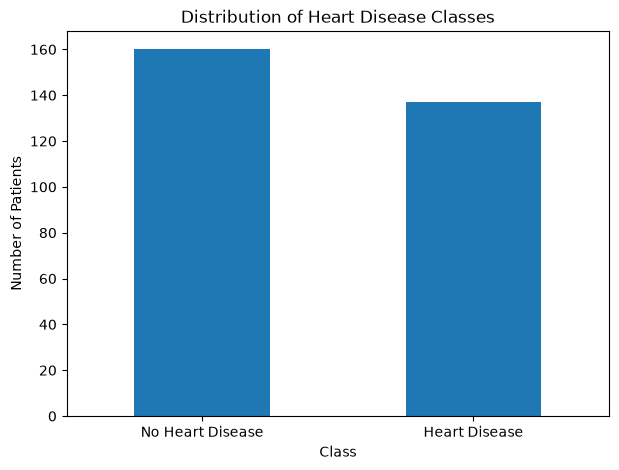

In [31]:
class_counts = df['target_label'].value_counts()

plt.figure(figsize=(7, 5))
class_counts.plot(kind='bar')

plt.title('Distribution of Heart Disease Classes')
plt.xlabel('Class')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

plt.show()

### Target Class Distribution

The binary target distribution is reasonably balanced. There are 160 patients without heart disease and 137 patients with heart disease, representing approximately 53.9% and 46.1% of the cleaned dataset respectively.

This balance is beneficial for classification because neither class is extremely under-represented. However, accuracy alone is still insufficient for model evaluation, because sensitivity and specificity are important for understanding how well each model identifies patients with and without heart disease.

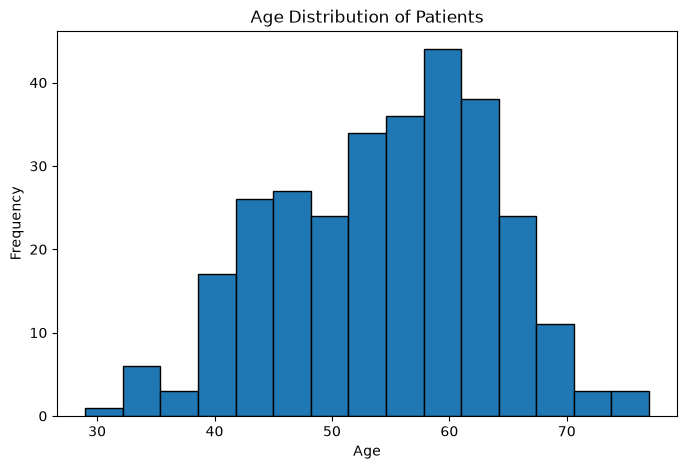

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(df['age'], bins=15, edgecolor='black')

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

<Figure size 800x500 with 0 Axes>

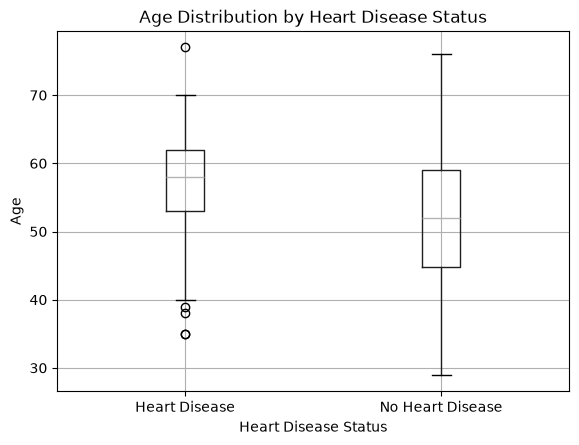

In [33]:
plt.figure(figsize=(8, 5))

df.boxplot(column='age', by='target_label')

plt.title('Age Distribution by Heart Disease Status')
plt.suptitle('')
plt.xlabel('Heart Disease Status')
plt.ylabel('Age')

plt.show()

In [34]:
df['sex'].value_counts().sort_index()

sex
0.0     96
1.0    201
Name: count, dtype: int64

### Continuous Feature Findings

The continuous-feature visualisations reveal several differences between the two target groups. Patients with heart disease generally tend to be older and achieve a lower maximum heart rate than patients without heart disease. The heart-disease group also tends to show higher exercise-induced ST depression values.

Resting blood pressure and serum cholesterol display considerable overlap between the two classes. This suggests that these variables may contain some predictive information but are unlikely to separate the classes effectively when considered individually. The exploratory results therefore support the use of multivariable machine-learning models that combine information across several clinical features.

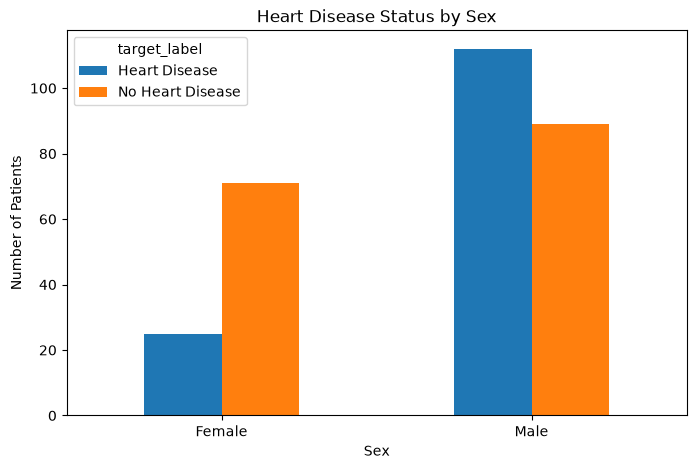

In [35]:
sex_target_counts = pd.crosstab(
    df['sex'],
    df['target_label']
)

sex_target_counts.index = ['Female', 'Male']

sex_target_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Heart Disease Status by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

plt.show()

### 4.2 Analysis of Key Clinical Features

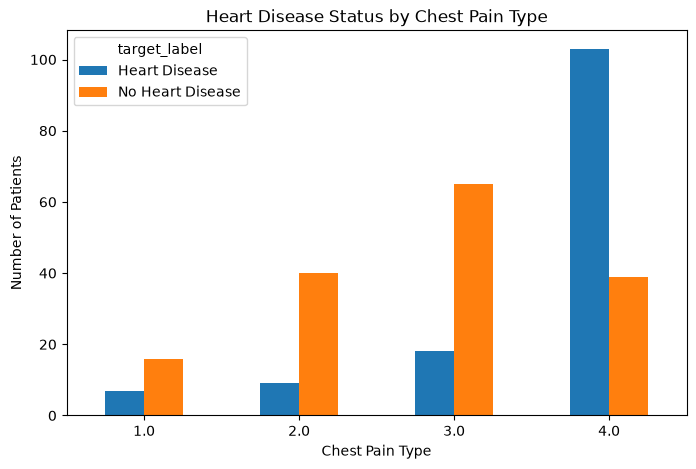

In [36]:
cp_target_counts = pd.crosstab(
    df['cp'],
    df['target_label']
)

cp_target_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Heart Disease Status by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

plt.show()

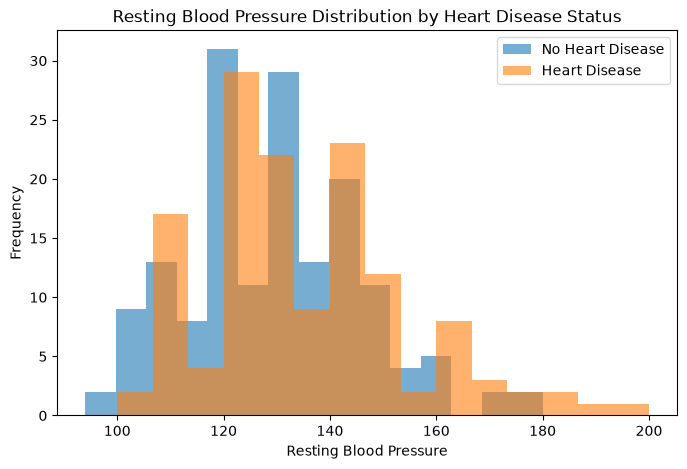

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df['target'] == 0]['trestbps'],
    bins=15,
    alpha=0.6,
    label='No Heart Disease'
)

plt.hist(
    df[df['target'] == 1]['trestbps'],
    bins=15,
    alpha=0.6,
    label='Heart Disease'
)

plt.title('Resting Blood Pressure Distribution by Heart Disease Status')
plt.xlabel('Resting Blood Pressure')
plt.ylabel('Frequency')
plt.legend()

plt.show()

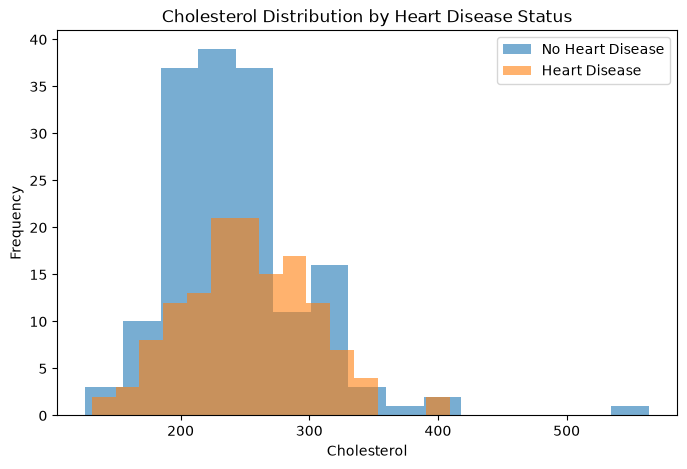

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df['target'] == 0]['chol'],
    bins=15,
    alpha=0.6,
    label='No Heart Disease'
)

plt.hist(
    df[df['target'] == 1]['chol'],
    bins=15,
    alpha=0.6,
    label='Heart Disease'
)

plt.title('Cholesterol Distribution by Heart Disease Status')
plt.xlabel('Cholesterol')
plt.ylabel('Frequency')
plt.legend()

plt.show()

<Figure size 800x500 with 0 Axes>

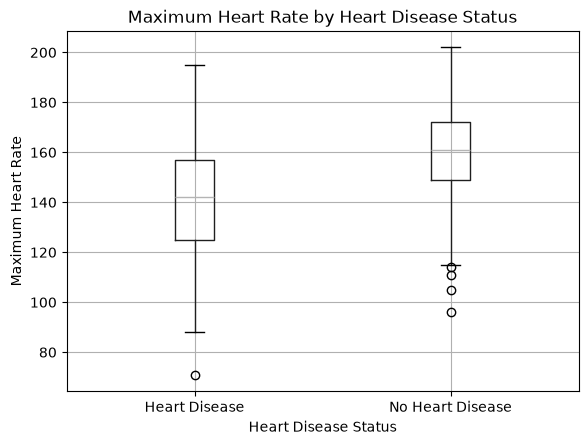

In [39]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='thalach',
    by='target_label'
)

plt.title('Maximum Heart Rate by Heart Disease Status')
plt.suptitle('')
plt.xlabel('Heart Disease Status')
plt.ylabel('Maximum Heart Rate')

plt.show()

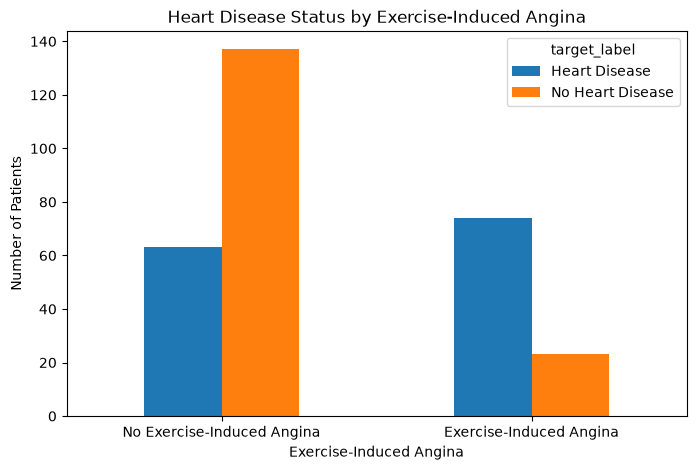

In [40]:
exang_target_counts = pd.crosstab(
    df['exang'],
    df['target_label']
)

exang_target_counts.index = [
    'No Exercise-Induced Angina',
    'Exercise-Induced Angina'
]

exang_target_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Heart Disease Status by Exercise-Induced Angina')
plt.xlabel('Exercise-Induced Angina')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

plt.show()

### 4.3 Further Feature Analysis and Correlation

<Figure size 800x500 with 0 Axes>

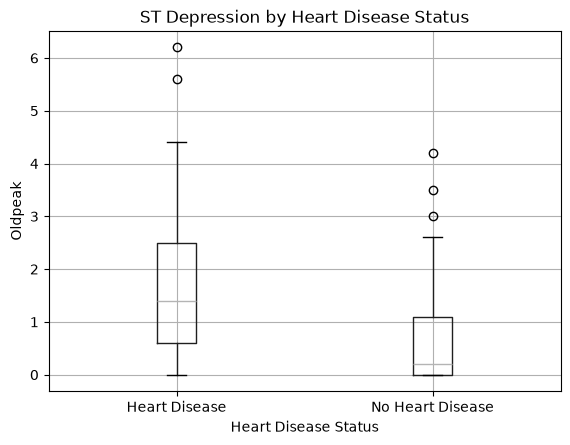

In [41]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='oldpeak',
    by='target_label'
)

plt.title('ST Depression by Heart Disease Status')
plt.suptitle('')
plt.xlabel('Heart Disease Status')
plt.ylabel('Oldpeak')

plt.show()

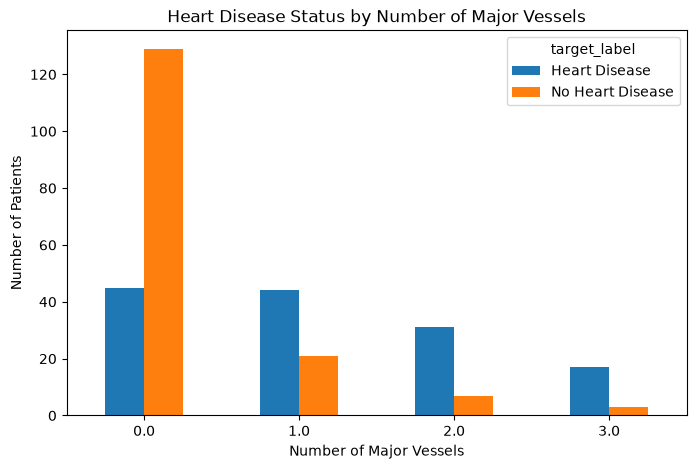

In [42]:
ca_target_counts = pd.crosstab(
    df['ca'],
    df['target_label']
)

ca_target_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Heart Disease Status by Number of Major Vessels')
plt.xlabel('Number of Major Vessels')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

plt.show()

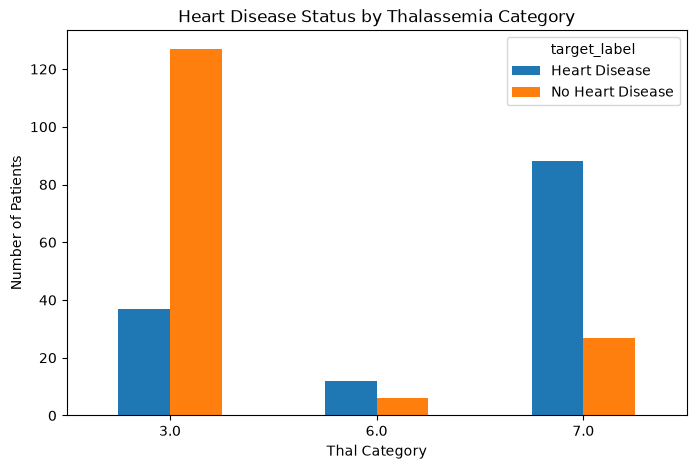

In [43]:
thal_target_counts = pd.crosstab(
    df['thal'],
    df['target_label']
)

thal_target_counts.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Heart Disease Status by Thalassemia Category')
plt.xlabel('Thal Category')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)

plt.show()

In [44]:
correlation_matrix = df.select_dtypes(
    include=['number']
).corr()

correlation_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.092399,0.110471,0.290476,0.202644,0.132062,0.149917,-0.394563,0.096489,0.197123,0.159405,0.362210,0.126586,0.227075
sex,-0.092399,1.000000,0.008908,-0.066340,-0.198089,0.038850,0.033897,-0.060496,0.143581,0.106567,0.033345,0.091925,0.383652,0.278467
cp,0.110471,0.008908,1.000000,-0.036980,0.072088,-0.057663,0.063905,-0.339308,0.377525,0.203244,0.151079,0.235644,0.268500,0.408945
trestbps,0.290476,-0.066340,-0.036980,1.000000,0.131536,0.180860,0.149242,-0.049108,0.066691,0.191243,0.121172,0.097954,0.138183,0.153490
chol,0.202644,-0.198089,0.072088,0.131536,1.000000,0.012708,0.165046,-0.000075,0.059339,0.038596,-0.009215,0.115945,0.010859,0.080285
fbs,0.132062,0.038850,-0.057663,0.180860,0.012708,1.000000,0.068831,-0.007842,-0.000893,0.008311,0.047819,0.152086,0.062209,0.003167
restecg,0.149917,0.033897,0.063905,0.149242,0.165046,0.068831,1.000000,-0.072290,0.081874,0.113726,0.135141,0.129021,0.018795,0.166343
thalach,-0.394563,-0.060496,-0.339308,-0.049108,-0.000075,-0.007842,-0.072290,1.000000,-0.384368,-0.347640,-0.389307,-0.268727,-0.274831,-0.423817
exang,0.096489,0.143581,0.377525,0.066691,0.059339,-0.000893,0.081874,-0.384368,1.000000,0.289310,0.250572,0.148232,0.326927,0.421355
oldpeak,0.197123,0.106567,0.203244,0.191243,0.038596,0.008311,0.113726,-0.347640,0.289310,1.000000,0.579037,0.294452,0.344976,0.424052


### Categorical Feature Findings

The categorical-feature comparisons show clear differences between the target groups for several variables. Chest pain type, exercise-induced angina, number of major vessels and thal are particularly associated with heart disease status.

Patients with exercise-induced angina appear more frequently in the heart-disease group. Higher coded values of the number of major vessels and abnormal thal categories are also more common among patients with heart disease. In contrast, fasting blood sugar and resting electrocardiographic results appear to provide weaker separation when considered independently.

These variables are stored using numerical codes, but the codes represent categories rather than continuous quantities. Therefore, their numerical differences should be interpreted cautiously during exploratory analysis.

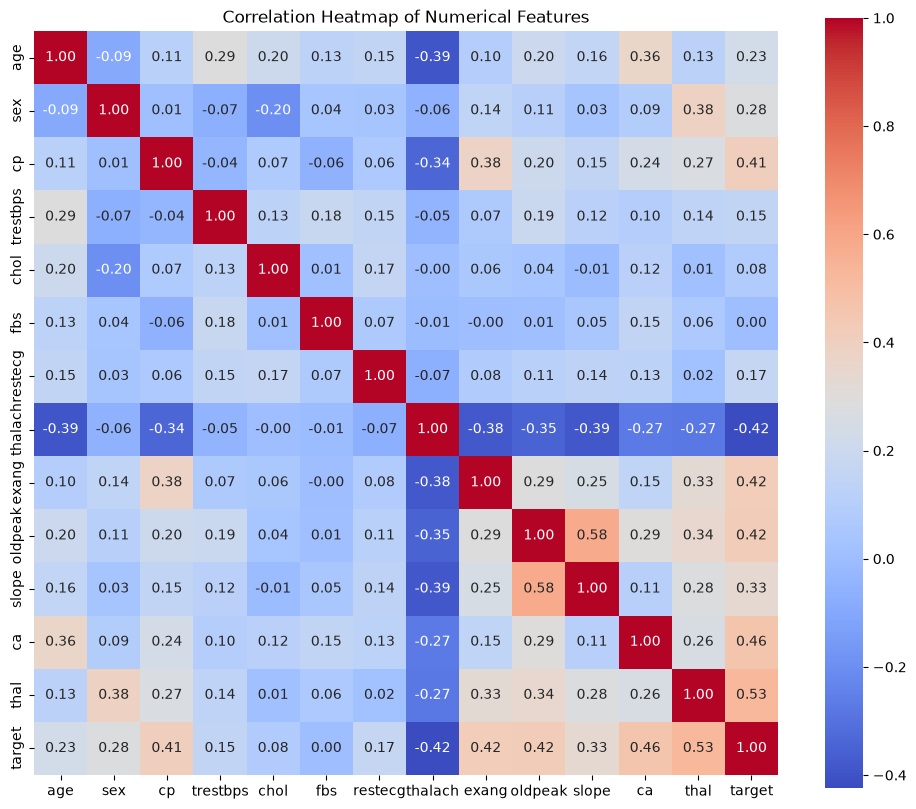

In [45]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)

plt.title('Correlation Heatmap of Numerical Features')

plt.show()

### Categorical Feature Findings

The categorical-feature comparisons show clear differences between the target groups for several variables. Chest pain type, exercise-induced angina, number of major vessels and thal are particularly associated with heart disease status.

Patients with exercise-induced angina appear more frequently in the heart-disease group. Higher coded values of the number of major vessels and abnormal thal categories are also more common among patients with heart disease. In contrast, fasting blood sugar and resting electrocardiographic results appear to provide weaker separation when considered independently.

These variables are stored using numerical codes, but the codes represent categories rather than continuous quantities. Therefore, their numerical differences should be interpreted cautiously during exploratory analysis.

### Summary of Exploratory Findings

The exploratory analysis identified several clinical variables that differed noticeably between patients with and without heart disease. The most informative patterns were observed for chest pain type, maximum heart rate, exercise-induced angina, oldpeak, number of major vessels and thal.

Patients with heart disease generally showed lower maximum heart rates and higher values of exercise-induced angina, oldpeak and number of major vessels. The target classes were reasonably balanced, meaning that both disease and non-disease observations were sufficiently represented for supervised classification.

No single variable completely separated the two target classes. Considerable overlap remained across many feature distributions, which indicates that heart disease status is more appropriately investigated using models that combine multiple clinical variables.

### Analytical Problem for Part II

Based on the exploratory findings, the main analytical problem addressed in Part II is:

**Can the available clinical characteristics be used to accurately classify whether a patient has heart disease?**

This problem is investigated using K-Nearest Neighbours, Naive Bayes, Logistic Regression, Decision Tree and Support Vector Machine models. Their performance is compared using accuracy, precision, sensitivity, specificity, F1-score, cross-validation and ROC-AUC.

A secondary exploratory question is also considered:

**Do the clinical variables reveal meaningful natural patient groups when the known heart disease labels are not used?**

This question is examined using K-Means and Hierarchical Clustering.

# Part II: Practical Skills Assessment – Data Analysis Process

## 5. Data Preprocessing for Machine Learning

In [46]:
X = df.drop(columns=['target', 'target_label'])
y = df['target']

In [47]:
X.shape, y.shape

((297, 13), (297,))

In [48]:
X.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [51]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (222, 13)
X_test shape: (75, 13)
y_train shape: (222,)
y_test shape: (75,)


### 5.1 Feature Scaling

In [52]:
from sklearn.preprocessing import StandardScaler

In [53]:
scaler = StandardScaler()

In [54]:
X_train_scaled = scaler.fit_transform(X_train)

In [55]:
X_test_scaled = scaler.transform(X_test)

In [56]:
print("Original training data:")
print(X_train.head())

print("\nScaled training data:")
print(X_train_scaled[:5])

Original training data:
      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
93   63.0  0.0  3.0     135.0  252.0  0.0      2.0    172.0    0.0      0.0   
184  42.0  1.0  3.0     120.0  240.0  1.0      0.0    194.0    0.0      0.8   
169  53.0  1.0  4.0     142.0  226.0  0.0      2.0    111.0    1.0      0.0   
146  41.0  1.0  3.0     112.0  250.0  0.0      0.0    179.0    0.0      0.0   
227  52.0  0.0  3.0     136.0  196.0  0.0      2.0    169.0    0.0      0.1   

     slope   ca  thal  
93     1.0  0.0   3.0  
184    3.0  0.0   7.0  
169    1.0  0.0   7.0  
146    1.0  0.0   3.0  
227    2.0  0.0   3.0  

Scaled training data:
[[ 0.92624842 -1.4735768  -0.19485627  0.15923375  0.04349965 -0.4472136
   1.01137167  0.9820026  -0.69995206 -0.88816817 -0.93929875 -0.7436577
  -0.92359548]
 [-1.41042373  0.67862089 -0.19485627 -0.67712016 -0.17892465  2.23606798
  -1.00230107  1.98390373 -0.69995206 -0.20826012  2.34454886 -0.7436577
   1.13708991]
 [-0.186452

## 6. Machine Learning Models

### 6.1 K-Nearest Neighbors (KNN)

K-Nearest Neighbours classifies an observation according to the labels of its nearest training examples (Cover and Hart, 1967).

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [58]:
knn = KNeighborsClassifier(n_neighbors=5)

In [59]:
knn.fit(X_train_scaled, y_train)

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2881: illegal multibyte sequence

UnicodeDecodeError: 'gbk' codec can't decode byte 0x94 in position 2881: illegal multibyte sequence

KNeighborsClassifier()

In [60]:
from sklearn import set_config

set_config(display='text')

In [61]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [62]:
y_pred_knn = knn.predict(X_test_scaled)

In [63]:
y_pred_knn[:10]

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 1])

In [64]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy (k=5):", knn_accuracy)

KNN Accuracy (k=5): 0.88


In [65]:
k_values = [1, 3, 5, 7]
k_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    k_accuracies.append(accuracy)

for k, accuracy in zip(k_values, k_accuracies):
    print(f"k={k}: Accuracy={accuracy:.4f}")

k=1: Accuracy=0.8000
k=3: Accuracy=0.9333
k=5: Accuracy=0.8800
k=7: Accuracy=0.8667


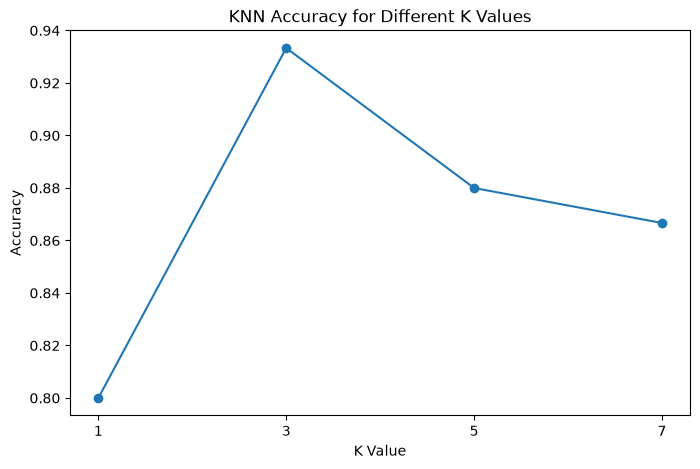

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    k_accuracies,
    marker='o'
)

plt.title('KNN Accuracy for Different K Values')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)

plt.show()

#### 6.1.1 K Value Selection Using Cross-Validation

In [67]:
from sklearn.model_selection import cross_val_score

In [68]:
k_range = range(1, 21)

In [69]:
cv_mean_scores = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=10,
        scoring='accuracy'
    )
    
    cv_mean_scores.append(scores.mean())

In [70]:
best_k = list(k_range)[np.argmax(cv_mean_scores)]
best_cv_score = max(cv_mean_scores)

print("Best k:", best_k)
print("Best 10-fold CV Accuracy:", round(best_cv_score, 4))

Best k: 20
Best 10-fold CV Accuracy: 0.8287


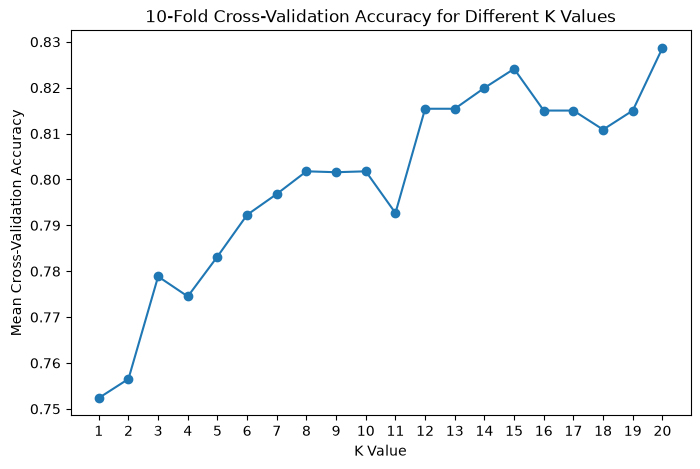

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_range),
    cv_mean_scores,
    marker='o'
)

plt.title('10-Fold Cross-Validation Accuracy for Different K Values')
plt.xlabel('K Value')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.xticks(list(k_range))

plt.show()

#### 6.1.2 Final KNN Model

In [72]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)

In [73]:
final_knn.fit(X_train_scaled, y_train)

print("Final KNN model trained successfully.")

Final KNN model trained successfully.


In [74]:
y_pred_final_knn = final_knn.predict(X_test_scaled)

In [75]:
final_knn_accuracy = accuracy_score(
    y_test,
    y_pred_final_knn
)

print(
    "Final KNN Test Accuracy:",
    round(final_knn_accuracy, 4)
)

Final KNN Test Accuracy: 0.8667


In [76]:
y_prob_final_knn = final_knn.predict_proba(X_test_scaled)[:, 1]

### 6.2 Naive Bayes

In [77]:
from sklearn.naive_bayes import GaussianNB

In [78]:
nb_model = GaussianNB()

In [79]:
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [80]:
y_pred_nb = nb_model.predict(X_test)

In [81]:
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", round(nb_accuracy, 4))

Naive Bayes Accuracy: 0.88


### 6.3 Logistic Regression

In [82]:
from sklearn.linear_model import LogisticRegression

In [83]:
logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [84]:
logreg_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [85]:
y_pred_logreg = logreg_model.predict(
    X_test_scaled
)

In [86]:
y_prob_logreg = logreg_model.predict_proba(
    X_test_scaled
)[:, 1]

logreg_accuracy = accuracy_score(
    y_test,
    y_pred_logreg
)

print(
    "Logistic Regression Accuracy:",
    round(logreg_accuracy, 4)
)

Logistic Regression Accuracy: 0.8533


### 6.4 Decision Tree

In [87]:
from sklearn.tree import DecisionTreeClassifier

In [88]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=42
)

In [89]:
dt_model.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [90]:
y_pred_dt = dt_model.predict(
    X_test
)

In [91]:
y_prob_dt = dt_model.predict_proba(
    X_test
)[:, 1]

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy, 4)
)

Decision Tree Accuracy: 0.6933


#### 6.4.1 Decision Tree Hyperparameter Tuning

In [92]:
from sklearn.model_selection import GridSearchCV

In [93]:
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 2, 3, 4, 5, 6, 8],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
}

In [94]:
dt_grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    scoring='accuracy',
    cv=10,
    n_jobs=-1
)

In [95]:
dt_grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 3, 4, 5, 6, 8],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 10, 15]},
             scoring='accuracy')

In [96]:
print("Best Decision Tree Parameters:")
print(dt_grid_search.best_params_)

print(
    "Best Decision Tree CV Accuracy:",
    round(dt_grid_search.best_score_, 4)
)

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 6, 'min_samples_split': 2}
Best Decision Tree CV Accuracy: 0.8065


#### 6.4.2 Final Decision Tree Model

In [97]:
final_dt_model = dt_grid_search.best_estimator_

print(final_dt_model)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=6,
                       random_state=42)


In [98]:
y_pred_final_dt = final_dt_model.predict(X_test)

In [99]:
y_prob_final_dt = final_dt_model.predict_proba(X_test)[:, 1]

In [100]:
final_dt_accuracy = accuracy_score(
    y_test,
    y_pred_final_dt
)

print(
    "Final Decision Tree Test Accuracy:",
    round(final_dt_accuracy, 4)
)

Final Decision Tree Test Accuracy: 0.7733


### 6.5 Support Vector Machine

Support Vector Machine constructs a decision boundary that maximises the separation between classes (Cortes and Vapnik, 1995).

In [101]:
from sklearn.svm import SVC

In [102]:
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

In [103]:
svm_model.fit(
    X_train_scaled,
    y_train
)

print("SVM model trained successfully.")

SVM model trained successfully.


In [104]:
y_pred_svm = svm_model.predict(
    X_test_scaled
)

In [105]:
y_score_svm = svm_model.decision_function(
    X_test_scaled
)

In [106]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print(
    "Initial SVM Accuracy:",
    round(svm_accuracy, 4)
)

Initial SVM Accuracy: 0.8533


#### 6.5.1 SVM Hyperparameter Tuning

In [107]:
svm_param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    }
]

In [108]:
from sklearn.model_selection import StratifiedKFold

svm_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [109]:
svm_grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=svm_param_grid,
    scoring='accuracy',
    cv=svm_cv,
    n_jobs=1,
    verbose=1
)

In [110]:
svm_grid_search.fit(
    X_train_scaled,
    y_train
)

Fitting 10 folds for each of 29 candidates, totalling 290 fits


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=SVC(), n_jobs=1,
             param_grid=[{'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['linear']},
                         {'C': [0.1, 1, 10, 100],
                          'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
                          'kernel': ['rbf']}],
             scoring='accuracy', verbose=1)

In [111]:
print("Best SVM Parameters:")
print(svm_grid_search.best_params_)

Best SVM Parameters:
{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}


In [112]:
print(
    "Best SVM CV Accuracy:",
    round(svm_grid_search.best_score_, 4)
)

Best SVM CV Accuracy: 0.833


#### 6.5.2 Final SVM Model

In [113]:
final_svm_model = svm_grid_search.best_estimator_

print(final_svm_model)

SVC(C=1, gamma=0.01)


In [114]:
y_pred_final_svm = final_svm_model.predict(
    X_test_scaled
)

In [115]:
y_score_final_svm = final_svm_model.decision_function(
    X_test_scaled
)

In [116]:
final_svm_accuracy = accuracy_score(
    y_test,
    y_pred_final_svm
)

print(
    "Final SVM Test Accuracy:",
    round(final_svm_accuracy, 4)
)

Final SVM Test Accuracy: 0.8667


In [117]:
print("Final SVM Configuration")
print("-----------------------")
print("Kernel:", final_svm_model.kernel)
print("C:", final_svm_model.C)
print("Gamma:", final_svm_model.gamma)

Final SVM Configuration
-----------------------
Kernel: rbf
C: 1
Gamma: 0.01


## 7. Model Evaluation and Results

The evaluation procedure followed the classification and model-evaluation methods introduced in the Machine Learning course materials (Zheng and Fu, 2026).

### 7.1 KNN Evaluation

In [118]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [119]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_final_knn
)

cm_knn

array([[37,  3],
       [ 7, 28]])

In [120]:
tn, fp, fn, tp = cm_knn.ravel()

print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)

True Negative: 37
False Positive: 3
False Negative: 7
True Positive: 28


In [121]:
accuracy_knn = accuracy_score(
    y_test,
    y_pred_final_knn
)

precision_knn = precision_score(
    y_test,
    y_pred_final_knn
)

sensitivity_knn = recall_score(
    y_test,
    y_pred_final_knn
)

specificity_knn = tn / (tn + fp)

f1_knn = f1_score(
    y_test,
    y_pred_final_knn
)

In [122]:
print("KNN Evaluation Results")
print("----------------------")
print("Accuracy:", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Sensitivity:", round(sensitivity_knn, 4))
print("Specificity:", round(specificity_knn, 4))
print("F1-score:", round(f1_knn, 4))

KNN Evaluation Results
----------------------
Accuracy: 0.8667
Precision: 0.9032
Sensitivity: 0.8
Specificity: 0.925
F1-score: 0.8485


### 7.2 KNN Visual Evaluation

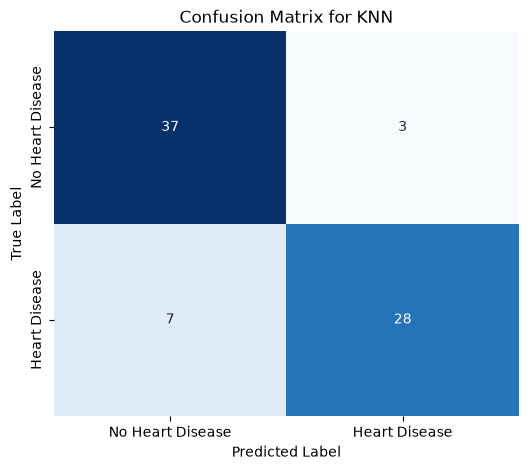

In [123]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No Heart Disease', 'Heart Disease'],
    yticklabels=['No Heart Disease', 'Heart Disease']
)

plt.title('Confusion Matrix for KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [124]:
from sklearn.metrics import roc_curve, roc_auc_score

In [125]:
fpr_knn, tpr_knn, thresholds_knn = roc_curve(
    y_test,
    y_prob_final_knn
)

In [126]:
auc_knn = roc_auc_score(
    y_test,
    y_prob_final_knn
)

print("KNN AUC:", round(auc_knn, 4))

KNN AUC: 0.9414


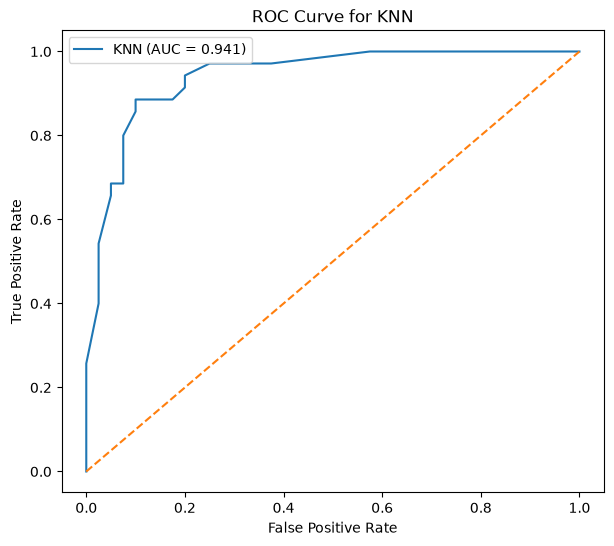

In [127]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f'KNN (AUC = {auc_knn:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.title('ROC Curve for KNN')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

### 7.3 Naive Bayes Evaluation

In [128]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

cm_nb

array([[36,  4],
       [ 5, 30]])

In [129]:
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()

print("True Negative:", tn_nb)
print("False Positive:", fp_nb)
print("False Negative:", fn_nb)
print("True Positive:", tp_nb)

True Negative: 36
False Positive: 4
False Negative: 5
True Positive: 30


In [130]:
accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

precision_nb = precision_score(
    y_test,
    y_pred_nb
)

sensitivity_nb = recall_score(
    y_test,
    y_pred_nb
)

specificity_nb = tn_nb / (tn_nb + fp_nb)

f1_nb = f1_score(
    y_test,
    y_pred_nb
)

In [131]:
print("Naive Bayes Evaluation Results")
print("------------------------------")
print("Accuracy:", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Sensitivity:", round(sensitivity_nb, 4))
print("Specificity:", round(specificity_nb, 4))
print("F1-score:", round(f1_nb, 4))

Naive Bayes Evaluation Results
------------------------------
Accuracy: 0.88
Precision: 0.8824
Sensitivity: 0.8571
Specificity: 0.9
F1-score: 0.8696


In [132]:
auc_nb = roc_auc_score(
    y_test,
    y_prob_nb
)

print("Naive Bayes AUC:", round(auc_nb, 4))

Naive Bayes AUC: 0.9279


### 7.4 Naive Bayes Visual Evaluation

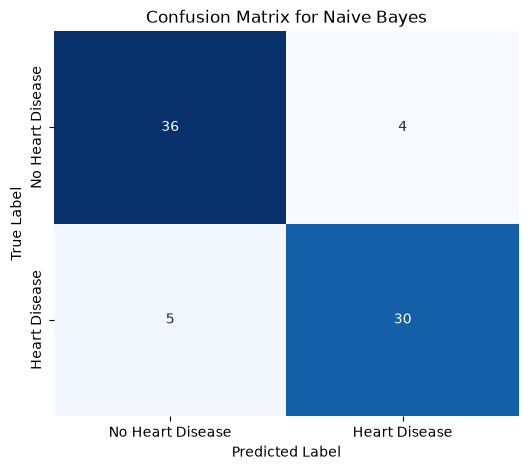

In [133]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No Heart Disease', 'Heart Disease'],
    yticklabels=['No Heart Disease', 'Heart Disease']
)

plt.title('Confusion Matrix for Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [134]:
fpr_nb, tpr_nb, thresholds_nb = roc_curve(
    y_test,
    y_prob_nb
)

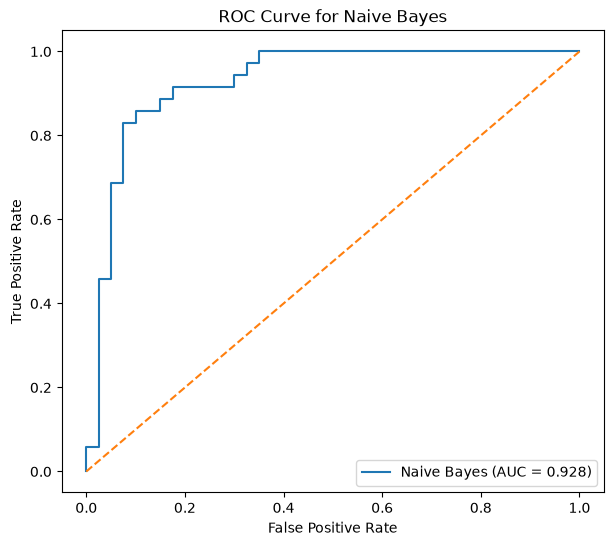

In [135]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f'Naive Bayes (AUC = {auc_nb:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.title('ROC Curve for Naive Bayes')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

In [136]:
results_table = pd.DataFrame({
    'Model': ['KNN', 'Naive Bayes'],
    'Accuracy': [accuracy_knn, accuracy_nb],
    'Precision': [precision_knn, precision_nb],
    'Sensitivity': [sensitivity_knn, sensitivity_nb],
    'Specificity': [specificity_knn, specificity_nb],
    'F1-score': [f1_knn, f1_nb],
    'AUC': [auc_knn, auc_nb]
})

results_table

,Model,Accuracy,Precision,Sensitivity,Specificity,F1-score,AUC
0,KNN,0.866667,0.903226,0.800000,0.925,0.848485,0.941429
1,Naive Bayes,0.880000,0.882353,0.857143,0.900,0.869565,0.927857


In [137]:
results_table.round(4)

,Model,Accuracy,Precision,Sensitivity,Specificity,F1-score,AUC
0,KNN,0.8667,0.9032,0.8000,0.925,0.8485,0.9414
1,Naive Bayes,0.8800,0.8824,0.8571,0.900,0.8696,0.9279


### 7.5 Logistic Regression Evaluation

In [138]:
cm_logreg = confusion_matrix(
    y_test,
    y_pred_logreg
)

cm_logreg

array([[35,  5],
       [ 6, 29]])

In [139]:
tn_logreg, fp_logreg, fn_logreg, tp_logreg = cm_logreg.ravel()

print("True Negative:", tn_logreg)
print("False Positive:", fp_logreg)
print("False Negative:", fn_logreg)
print("True Positive:", tp_logreg)

True Negative: 35
False Positive: 5
False Negative: 6
True Positive: 29


In [140]:
accuracy_logreg = accuracy_score(
    y_test,
    y_pred_logreg
)

precision_logreg = precision_score(
    y_test,
    y_pred_logreg
)

sensitivity_logreg = recall_score(
    y_test,
    y_pred_logreg
)

specificity_logreg = tn_logreg / (tn_logreg + fp_logreg)

f1_logreg = f1_score(
    y_test,
    y_pred_logreg
)

In [141]:
auc_logreg = roc_auc_score(
    y_test,
    y_prob_logreg
)

In [142]:
print("Logistic Regression Evaluation Results")
print("--------------------------------------")
print("Accuracy:", round(accuracy_logreg, 4))
print("Precision:", round(precision_logreg, 4))
print("Sensitivity:", round(sensitivity_logreg, 4))
print("Specificity:", round(specificity_logreg, 4))
print("F1-score:", round(f1_logreg, 4))
print("AUC:", round(auc_logreg, 4))

Logistic Regression Evaluation Results
--------------------------------------
Accuracy: 0.8533
Precision: 0.8529
Sensitivity: 0.8286
Specificity: 0.875
F1-score: 0.8406
AUC: 0.9471


### 7.6 Logistic Regression Visual Evaluation

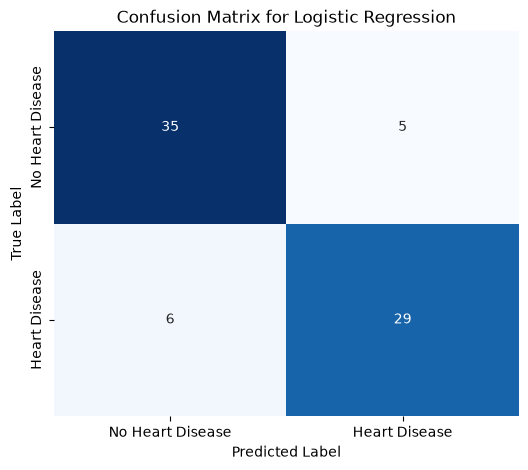

In [143]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logreg,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No Heart Disease', 'Heart Disease'],
    yticklabels=['No Heart Disease', 'Heart Disease']
)

plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [144]:
fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(
    y_test,
    y_prob_logreg
)

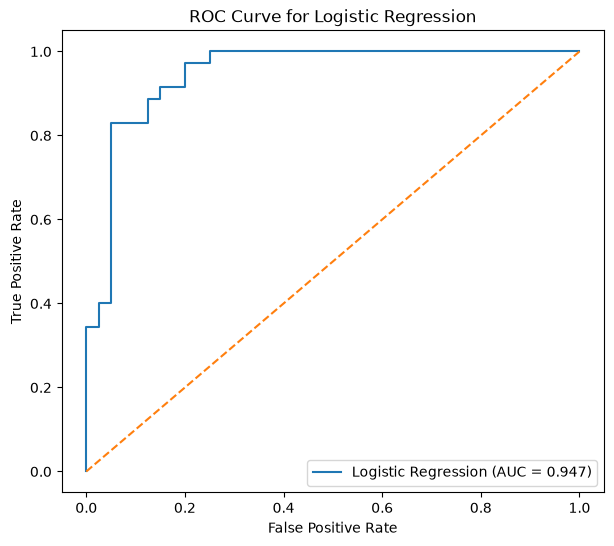

In [145]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_logreg,
    tpr_logreg,
    label=f'Logistic Regression (AUC = {auc_logreg:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.title('ROC Curve for Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

### 7.7 Decision Tree Evaluation

In [146]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_final_dt
)

In [147]:
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()

accuracy_dt = accuracy_score(
    y_test,
    y_pred_final_dt
)

precision_dt = precision_score(
    y_test,
    y_pred_final_dt
)

sensitivity_dt = recall_score(
    y_test,
    y_pred_final_dt
)
specificity_dt = tn_dt / (tn_dt + fp_dt)

f1_dt = f1_score(
    y_test,
    y_pred_final_dt
)

In [148]:
auc_dt = roc_auc_score(
    y_test,
    y_prob_final_dt
)

In [149]:
print("Final Decision Tree Evaluation Results")
print("--------------------------------")
print("Accuracy:", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Sensitivity:", round(sensitivity_dt, 4))
print("Specificity:", round(specificity_dt, 4))
print("F1-score:", round(f1_dt, 4))
print("AUC:", round(auc_dt, 4))

Final Decision Tree Evaluation Results
--------------------------------
Accuracy: 0.7733
Precision: 0.875
Sensitivity: 0.6
Specificity: 0.925
F1-score: 0.7119
AUC: 0.7757


### 7.8 Decision Tree Visual Evaluation

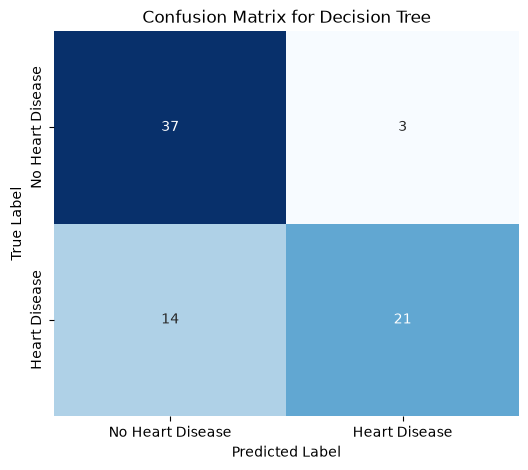

In [150]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No Heart Disease', 'Heart Disease'],
    yticklabels=['No Heart Disease', 'Heart Disease']
)

plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [151]:
fpr_dt, tpr_dt, thresholds_dt = roc_curve(
    y_test,
    y_prob_final_dt
)

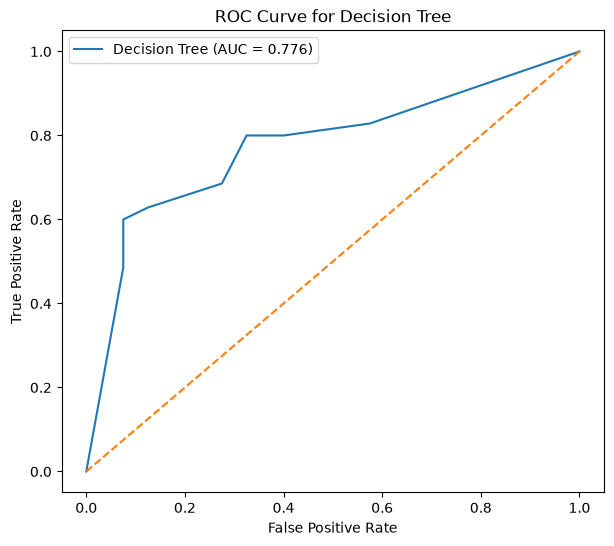

In [152]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {auc_dt:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.title('ROC Curve for Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

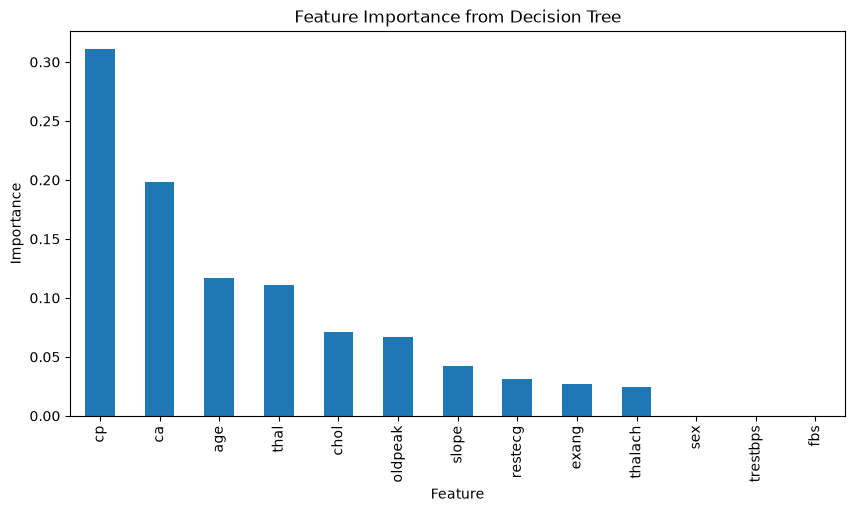

In [153]:
feature_importance = pd.Series(
    final_dt_model.feature_importances_,
    index=X_train.columns
)

feature_importance.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Feature Importance from Decision Tree')
plt.xlabel('Feature')
plt.ylabel('Importance')

plt.show()

### 7.9 Support Vector Machine Evaluation

In [154]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_final_svm
)

cm_svm

array([[36,  4],
       [ 6, 29]])

In [155]:
tn_svm, fp_svm, fn_svm, tp_svm = cm_svm.ravel()

print("True Negative:", tn_svm)
print("False Positive:", fp_svm)
print("False Negative:", fn_svm)
print("True Positive:", tp_svm)

True Negative: 36
False Positive: 4
False Negative: 6
True Positive: 29


In [156]:
accuracy_svm = accuracy_score(
    y_test,
    y_pred_final_svm
)

precision_svm = precision_score(
    y_test,
    y_pred_final_svm
)

sensitivity_svm = recall_score(
    y_test,
    y_pred_final_svm
)

specificity_svm = tn_svm / (tn_svm + fp_svm)

f1_svm = f1_score(
    y_test,
    y_pred_final_svm
)

In [157]:
auc_svm = roc_auc_score(
    y_test,
    y_score_final_svm
)

In [158]:
print("Final SVM Evaluation Results")
print("----------------------------")
print("Accuracy:", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Sensitivity:", round(sensitivity_svm, 4))
print("Specificity:", round(specificity_svm, 4))
print("F1-score:", round(f1_svm, 4))
print("AUC:", round(auc_svm, 4))

Final SVM Evaluation Results
----------------------------
Accuracy: 0.8667
Precision: 0.8788
Sensitivity: 0.8286
Specificity: 0.9
F1-score: 0.8529
AUC: 0.9529


### 7.10 Support Vector Machine Visual Evaluation

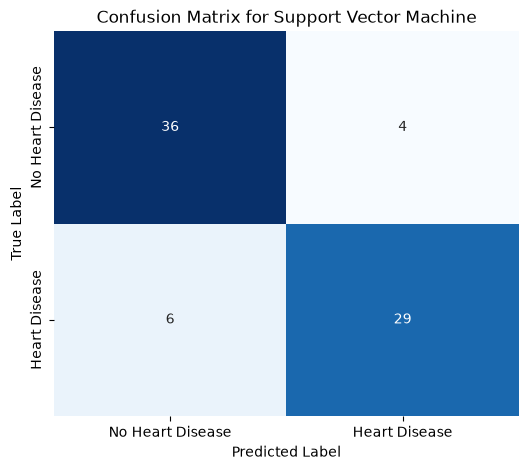

In [159]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No Heart Disease', 'Heart Disease'],
    yticklabels=['No Heart Disease', 'Heart Disease']
)

plt.title('Confusion Matrix for Support Vector Machine')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [160]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(
    y_test,
    y_score_final_svm
)

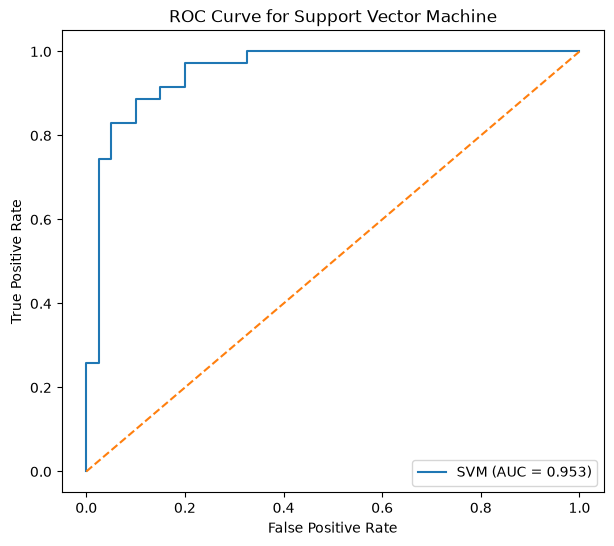

In [161]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f'SVM (AUC = {auc_svm:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.title('ROC Curve for Support Vector Machine')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

In [162]:
results_table = pd.DataFrame({
    'Model': [
        'KNN',
        'Naive Bayes',
        'Logistic Regression',
        'Decision Tree',
        'Support Vector Machine'
    ],

    'Accuracy': [
        accuracy_knn,
        accuracy_nb,
        accuracy_logreg,
        accuracy_dt,
        accuracy_svm
    ],

    'Precision': [
        precision_knn,
        precision_nb,
        precision_logreg,
        precision_dt,
        precision_svm
    ],

    'Sensitivity': [
        sensitivity_knn,
        sensitivity_nb,
        sensitivity_logreg,
        sensitivity_dt,
        sensitivity_svm
    ],

    'Specificity': [
        specificity_knn,
        specificity_nb,
        specificity_logreg,
        specificity_dt,
        specificity_svm
    ],

    'F1-score': [
        f1_knn,
        f1_nb,
        f1_logreg,
        f1_dt,
        f1_svm
    ],

    'AUC': [
        auc_knn,
        auc_nb,
        auc_logreg,
        auc_dt,
        auc_svm
    ]
})

results_table.round(4)

,Model,Accuracy,Precision,Sensitivity,Specificity,F1-score,AUC
0,KNN,0.8667,0.9032,0.8000,0.925,0.8485,0.9414
1,Naive Bayes,0.8800,0.8824,0.8571,0.900,0.8696,0.9279
2,Logistic Regression,0.8533,0.8529,0.8286,0.875,0.8406,0.9471
3,Decision Tree,0.7733,0.8750,0.6000,0.925,0.7119,0.7757
4,Support Vector Machine,0.8667,0.8788,0.8286,0.900,0.8529,0.9529


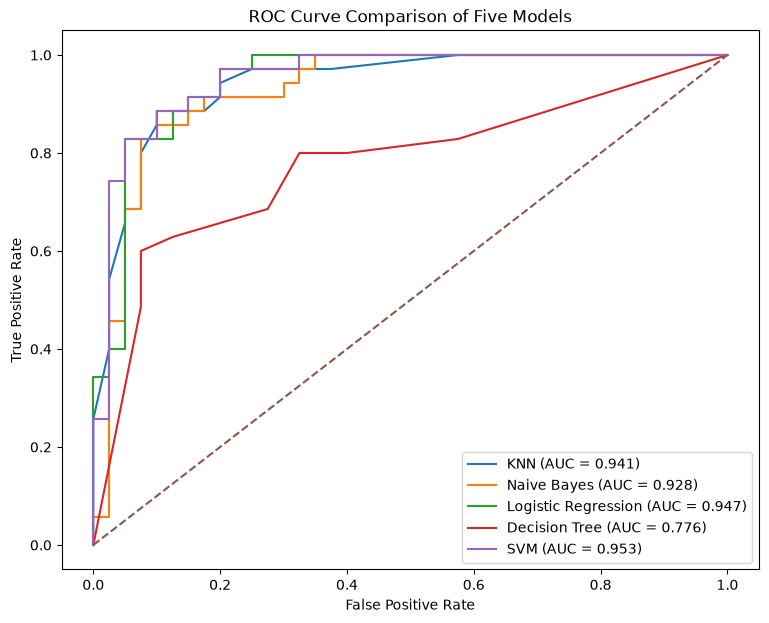

In [163]:
plt.figure(figsize=(9, 7))

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f'KNN (AUC = {auc_knn:.3f})'
)

plt.plot(
    fpr_nb,
    tpr_nb,
    label=f'Naive Bayes (AUC = {auc_nb:.3f})'
)

plt.plot(
    fpr_logreg,
    tpr_logreg,
    label=f'Logistic Regression (AUC = {auc_logreg:.3f})'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {auc_dt:.3f})'
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f'SVM (AUC = {auc_svm:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.title('ROC Curve Comparison of Five Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.show()

### 7.11 Quantitative Model Comparison

In [164]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [165]:
comparison_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

In [166]:
comparison_models = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=best_k))
    ]),

    'Naive Bayes': GaussianNB(),

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    'Decision Tree': DecisionTreeClassifier(
        criterion='entropy',
        max_depth=4,
        min_samples_leaf=6,
        min_samples_split=2,
        random_state=42
    ),

    'Support Vector Machine': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            kernel='rbf',
            C=1,
            gamma=0.01
        ))
    ])
}

In [167]:
cv_results = {}

for model_name, model in comparison_models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=comparison_cv,
        scoring='accuracy'
    )

    cv_results[model_name] = {
        'CV Mean Accuracy': scores.mean(),
        'CV Standard Deviation': scores.std()
    }

In [168]:
cv_results_table = pd.DataFrame(
    cv_results
).T

cv_results_table.round(4)

,CV Mean Accuracy,CV Standard Deviation
KNN,0.8285,0.0717
Naive Bayes,0.8317,0.0774
Logistic Regression,0.8248,0.0471
Decision Tree,0.7645,0.0773
Support Vector Machine,0.8318,0.0554


In [169]:
test_results_table = results_table.copy()

test_results_table = test_results_table.set_index('Model')

test_results_table.round(4)

,Accuracy,Precision,Sensitivity,Specificity,F1-score,AUC
Model,,,,,,
KNN,0.8667,0.9032,0.8000,0.925,0.8485,0.9414
Naive Bayes,0.8800,0.8824,0.8571,0.900,0.8696,0.9279
Logistic Regression,0.8533,0.8529,0.8286,0.875,0.8406,0.9471
Decision Tree,0.7733,0.8750,0.6000,0.925,0.7119,0.7757
Support Vector Machine,0.8667,0.8788,0.8286,0.900,0.8529,0.9529


In [170]:
final_comparison_table = test_results_table.join(
    cv_results_table
)

final_comparison_table.round(4)

,Accuracy,Precision,Sensitivity,Specificity,F1-score,AUC,CV Mean Accuracy,CV Standard Deviation
Model,,,,,,,,
KNN,0.8667,0.9032,0.8000,0.925,0.8485,0.9414,0.8285,0.0717
Naive Bayes,0.8800,0.8824,0.8571,0.900,0.8696,0.9279,0.8317,0.0774
Logistic Regression,0.8533,0.8529,0.8286,0.875,0.8406,0.9471,0.8248,0.0471
Decision Tree,0.7733,0.8750,0.6000,0.925,0.7119,0.7757,0.7645,0.0773
Support Vector Machine,0.8667,0.8788,0.8286,0.900,0.8529,0.9529,0.8318,0.0554


In [171]:
final_comparison_table_sorted = final_comparison_table.sort_values(
    by='CV Mean Accuracy',
    ascending=False
)

final_comparison_table_sorted.round(4)

,Accuracy,Precision,Sensitivity,Specificity,F1-score,AUC,CV Mean Accuracy,CV Standard Deviation
Model,,,,,,,,
Support Vector Machine,0.8667,0.8788,0.8286,0.900,0.8529,0.9529,0.8318,0.0554
Naive Bayes,0.8800,0.8824,0.8571,0.900,0.8696,0.9279,0.8317,0.0774
KNN,0.8667,0.9032,0.8000,0.925,0.8485,0.9414,0.8285,0.0717
Logistic Regression,0.8533,0.8529,0.8286,0.875,0.8406,0.9471,0.8248,0.0471
Decision Tree,0.7733,0.8750,0.6000,0.925,0.7119,0.7757,0.7645,0.0773


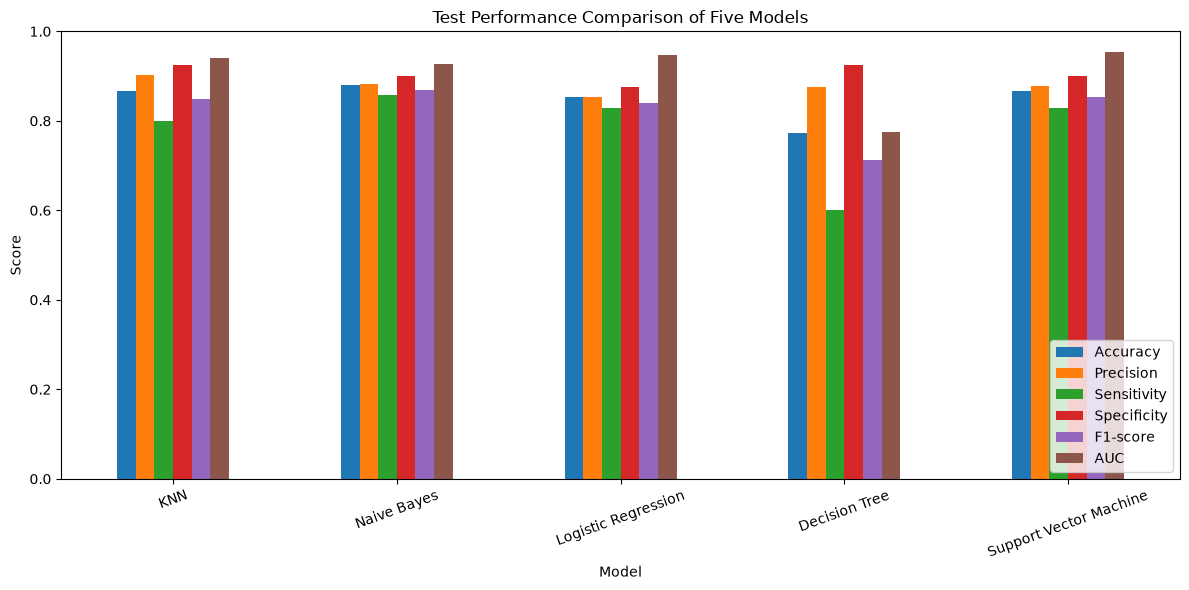

In [172]:
comparison_metrics = [
    'Accuracy',
    'Precision',
    'Sensitivity',
    'Specificity',
    'F1-score',
    'AUC'
]

final_comparison_table[
    comparison_metrics
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Test Performance Comparison of Five Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

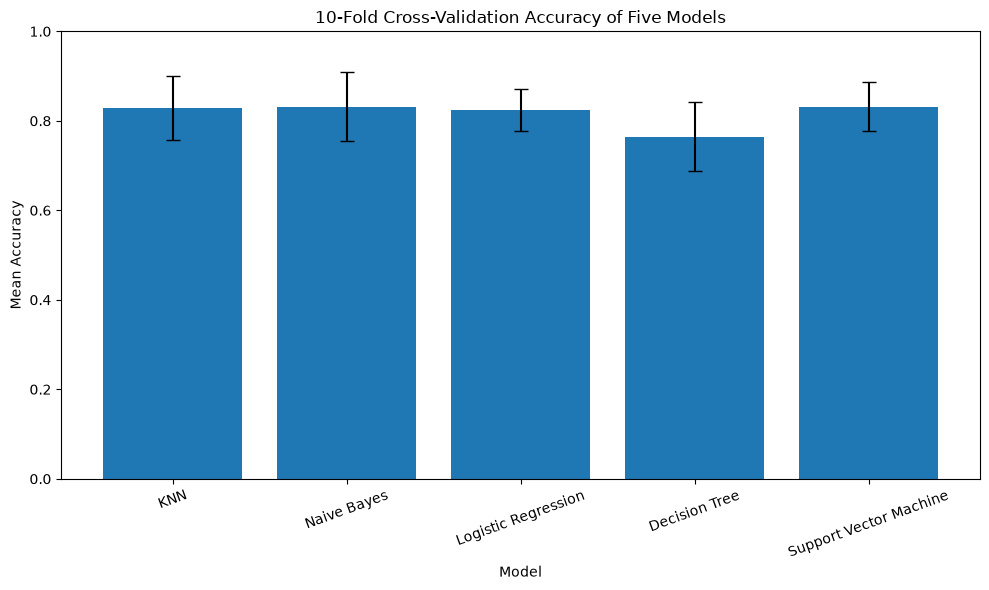

In [173]:
plt.figure(figsize=(10, 6))

plt.bar(
    cv_results_table.index,
    cv_results_table['CV Mean Accuracy'],
    yerr=cv_results_table['CV Standard Deviation'],
    capsize=5
)

plt.title('10-Fold Cross-Validation Accuracy of Five Models')
plt.xlabel('Model')
plt.ylabel('Mean Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

### 7.12 Practical Model Comparison

In [174]:
practical_comparison = pd.DataFrame({
    'Model': [
        'KNN',
        'Naive Bayes',
        'Logistic Regression',
        'Decision Tree',
        'Support Vector Machine'
    ],
    'Scaling Required': [
        'Yes',
        'No',
        'Recommended',
        'No',
        'Yes'
    ],
    'Interpretability': [
        'Medium',
        'Medium',
        'High',
        'High',
        'Low'
    ],
    'Non-linear Capability': [
        'Yes',
        'Limited',
        'No',
        'Yes',
        'Yes'
    ],
    'Main Strength': [
        'Simple and flexible',
        'Fast probabilistic classification',
        'Stable and interpretable',
        'Clear decision rules',
        'Strong overall discrimination'
    ],
    'Main Limitation': [
        'Sensitive to scaling and k',
        'Assumes feature independence',
        'Assumes a linear decision boundary',
        'Prone to overfitting',
        'Less interpretable'
    ]
})

practical_comparison

,Model,Scaling Required,Interpretability,Non-linear Capability,Main Strength,Main Limitation
0,KNN,Yes,Medium,Yes,Simple and flexible,Sensitive to scaling and k
1,Naive Bayes,No,Medium,Limited,Fast probabilistic classification,Assumes feature independence
2,Logistic Regression,Recommended,High,No,Stable and interpretable,Assumes a linear decision boundary
3,Decision Tree,No,High,Yes,Clear decision rules,Prone to overfitting
4,Support Vector Machine,Yes,Low,Yes,Strong overall discrimination,Less interpretable


In [175]:
best_test_models = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Sensitivity',
        'Specificity',
        'F1-score',
        'AUC'
    ],
    'Best Model': [
        final_comparison_table['Accuracy'].idxmax(),
        final_comparison_table['Precision'].idxmax(),
        final_comparison_table['Sensitivity'].idxmax(),
        final_comparison_table['Specificity'].idxmax(),
        final_comparison_table['F1-score'].idxmax(),
        final_comparison_table['AUC'].idxmax()
    ],
    'Best Score': [
        final_comparison_table['Accuracy'].max(),
        final_comparison_table['Precision'].max(),
        final_comparison_table['Sensitivity'].max(),
        final_comparison_table['Specificity'].max(),
        final_comparison_table['F1-score'].max(),
        final_comparison_table['AUC'].max()
    ]
})

best_test_models.round(4)

,Metric,Best Model,Best Score
0,Accuracy,Naive Bayes,0.8800
1,Precision,KNN,0.9032
2,Sensitivity,Naive Bayes,0.8571
3,Specificity,KNN,0.9250
4,F1-score,Naive Bayes,0.8696
5,AUC,Support Vector Machine,0.9529


In [176]:
best_cv_model = cv_results_table[
    'CV Mean Accuracy'
].idxmax()

best_cv_accuracy = cv_results_table[
    'CV Mean Accuracy'
].max()

most_stable_model = cv_results_table[
    'CV Standard Deviation'
].idxmin()

lowest_cv_std = cv_results_table[
    'CV Standard Deviation'
].min()

print("Highest CV Mean Accuracy:", best_cv_model)
print("CV Mean Accuracy:", round(best_cv_accuracy, 4))

print("\nMost Stable Model:", most_stable_model)
print("Lowest CV Standard Deviation:", round(lowest_cv_std, 4))

Highest CV Mean Accuracy: Support Vector Machine
CV Mean Accuracy: 0.8318

Most Stable Model: Logistic Regression
Lowest CV Standard Deviation: 0.0471


#### Classification Model Summary

The five classification models showed different strengths across the evaluation criteria. Support Vector Machine achieved the highest mean 10-fold cross-validation accuracy of 0.8318 and the highest test AUC of 0.9529, indicating strong overall discrimination between patients with and without heart disease. Naive Bayes produced a very similar cross-validation accuracy of 0.8317 and achieved strong test performance despite its simplifying assumption that predictor variables are conditionally independent.

Logistic Regression had the lowest cross-validation standard deviation of 0.0471, suggesting that it was the most stable model across different data partitions. It also retained relatively high interpretability compared with SVM. The tuned Decision Tree achieved high specificity but substantially lower sensitivity, indicating that it was better at identifying patients without heart disease than detecting all patients with the disease.

Considering predictive performance, cross-validation stability and ROC-AUC, Support Vector Machine was selected as the strongest overall classification model. However, Logistic Regression may be preferable when model interpretability and stability are prioritised.

## 8. Unsupervised Clustering Analysis

The clustering workflow was informed by the clustering-analysis materials provided in the Machine Learning course (Zheng and Fu, 2026).

### 8.1 Data Preparation for Clustering

In [177]:
X_cluster = df.drop(
    columns=['target', 'target_label']
)

X_cluster.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


In [178]:
print("Clustering data shape:", X_cluster.shape)
print("Number of features:", X_cluster.shape[1])

Clustering data shape: (297, 13)
Number of features: 13


In [179]:
X_cluster.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

In [180]:
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(
    X_cluster
)

In [181]:
print("Scaled clustering data shape:", X_cluster_scaled.shape)

print(
    "Mean of first five scaled features:",
    np.round(X_cluster_scaled.mean(axis=0)[:5], 4)
)

print(
    "Standard deviation of first five scaled features:",
    np.round(X_cluster_scaled.std(axis=0)[:5], 4)
)

Scaled clustering data shape: (297, 13)
Mean of first five scaled features: [-0. -0. -0.  0. -0.]
Standard deviation of first five scaled features: [1. 1. 1. 1. 1.]


### 8.2 K-Means Clustering

K-Means partitions observations into clusters by minimising within-cluster variation (MacQueen, 1967).

In [182]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

The Silhouette Score was used to evaluate cluster cohesion and separation, with higher values indicating more clearly separated clusters (Rousseeuw, 1987).

In [183]:
inertia_values = []
silhouette_values = []

k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(
        X_cluster_scaled
    )
    
    inertia_values.append(
        kmeans.inertia_
    )
    
    silhouette_values.append(
        silhouette_score(
            X_cluster_scaled,
            cluster_labels
        )
    )

In [184]:
kmeans_evaluation = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertia_values,
    'Silhouette Score': silhouette_values
})

kmeans_evaluation.round(4)

,k,Inertia,Silhouette Score
0,2,3193.4531,0.1751
1,3,2931.1479,0.1298
2,4,2743.7743,0.1304
3,5,2609.7971,0.1127
4,6,2507.2835,0.1137
5,7,2404.5486,0.1013
6,8,2318.4530,0.1060


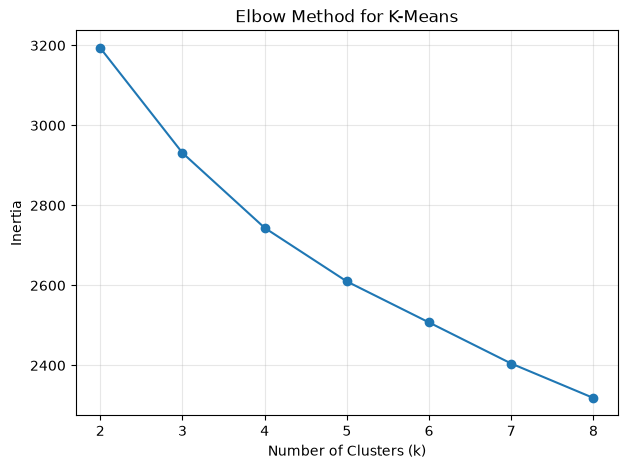

In [185]:
plt.figure(figsize=(7, 5))

plt.plot(
    list(k_range),
    inertia_values,
    marker='o'
)

plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)

plt.show()

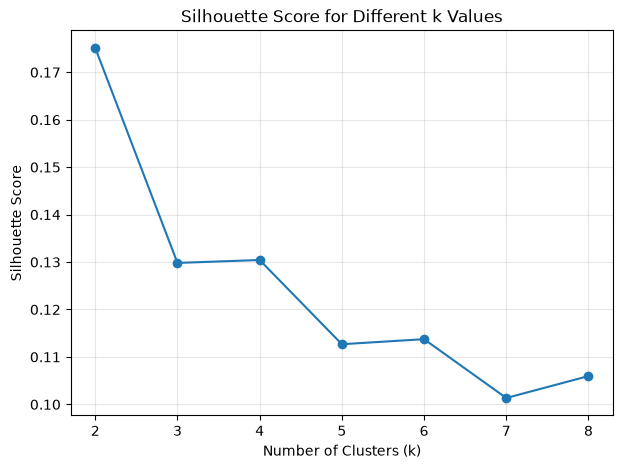

In [186]:
plt.figure(figsize=(7, 5))

plt.plot(
    list(k_range),
    silhouette_values,
    marker='o'
)

plt.title('Silhouette Score for Different k Values')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)

plt.show()

In [187]:
best_k_silhouette = list(k_range)[
    np.argmax(silhouette_values)
]

best_silhouette_score = max(
    silhouette_values
)

print(
    "Best k according to Silhouette Score:",
    best_k_silhouette
)

print(
    "Highest Silhouette Score:",
    round(best_silhouette_score, 4)
)

Best k according to Silhouette Score: 2
Highest Silhouette Score: 0.1751


#### 8.2.1 Final K-Means Model

In [188]:
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

In [189]:
kmeans_labels = final_kmeans.fit_predict(
    X_cluster_scaled
)

In [190]:
cluster_results_df = df.copy()

cluster_results_df['kmeans_cluster'] = kmeans_labels

In [191]:
cluster_counts = cluster_results_df[
    'kmeans_cluster'
].value_counts().sort_index()

cluster_counts

kmeans_cluster
0    184
1    113
Name: count, dtype: int64

In [192]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

kmeans_silhouette = silhouette_score(
    X_cluster_scaled,
    kmeans_labels
)

kmeans_db = davies_bouldin_score(
    X_cluster_scaled,
    kmeans_labels
)

kmeans_ch = calinski_harabasz_score(
    X_cluster_scaled,
    kmeans_labels
)

print("Final K-Means Evaluation")
print("------------------------")
print("Silhouette Score:", round(kmeans_silhouette, 4))
print("Davies-Bouldin Index:", round(kmeans_db, 4))
print("Calinski-Harabasz Score:", round(kmeans_ch, 4))

Final K-Means Evaluation
------------------------
Silhouette Score: 0.1751
Davies-Bouldin Index: 2.0792
Calinski-Harabasz Score: 61.6656


#### 8.2.2 K-Means Cluster Visualisation

Principal Component Analysis was used to project the standardised 13-dimensional feature space into two dimensions for visualisation (Jolliffe and Cadima, 2016).

In [193]:
from sklearn.decomposition import PCA

In [194]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_cluster_scaled
)

In [195]:
print(
    "Explained variance ratio:"
)

print(
    np.round(
        pca.explained_variance_ratio_,
        4
    )
)

print(
    "Total explained variance:",
    round(
        sum(pca.explained_variance_ratio_),
        4
    )
)

Explained variance ratio:
[0.237  0.1235]
Total explained variance: 0.3604


In [196]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        'PC1',
        'PC2'
    ]
)

pca_df['Cluster'] = kmeans_labels

pca_df.head()

,PC1,PC2,Cluster
0,1.130664,-1.087655,1
1,3.190926,-1.417885,1
2,3.124339,0.657008,1
3,-0.484339,1.410972,0
4,-2.284542,-0.330033,0


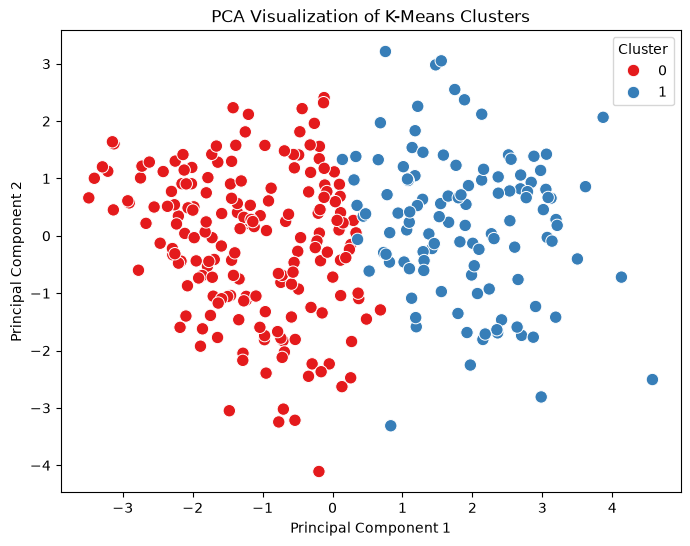

In [197]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.title(
    'PCA Visualization of K-Means Clusters'
)

plt.xlabel(
    'Principal Component 1'
)

plt.ylabel(
    'Principal Component 2'
)

plt.legend(
    title='Cluster'
)

plt.show()

### 8.3 Hierarchical Clustering

In [198]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

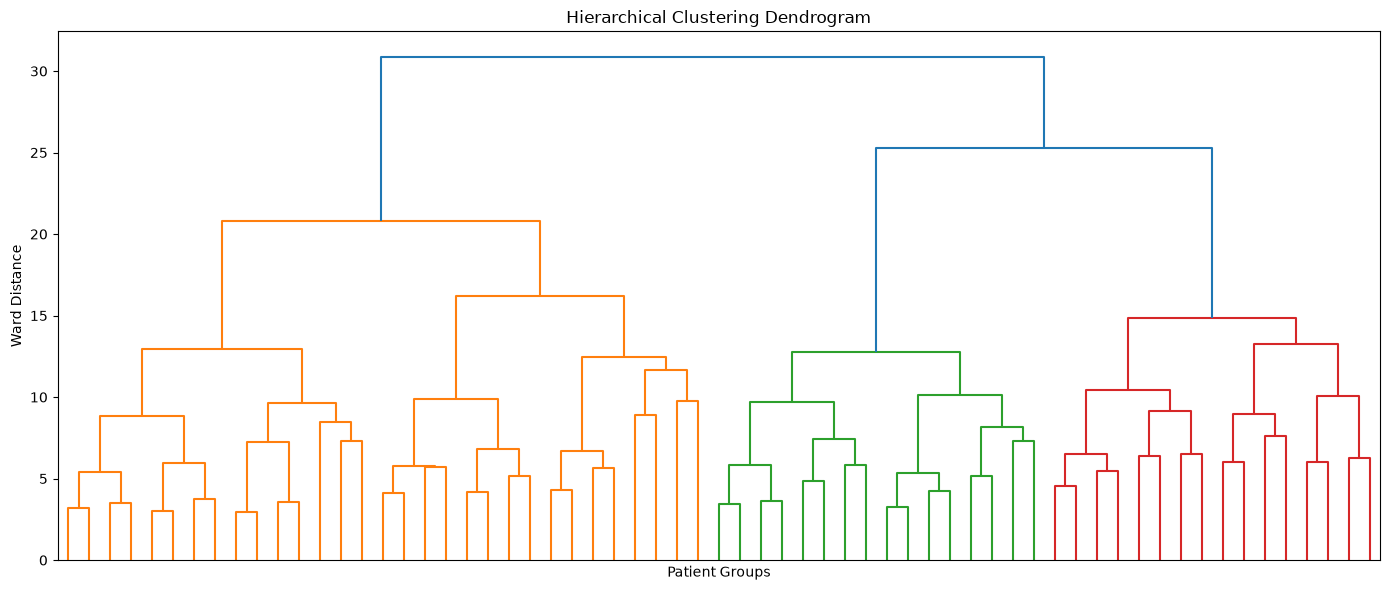

In [199]:
hierarchical_linkage = linkage(
    X_cluster_scaled,
    method='ward'
)

plt.figure(figsize=(14, 6))

dendrogram(
    hierarchical_linkage,
    truncate_mode='level',
    p=5,
    no_labels=True
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Patient Groups')
plt.ylabel('Ward Distance')
plt.tight_layout()

plt.show()

In [200]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_cluster_scaled
)

In [201]:
hierarchical_counts = pd.Series(
    hierarchical_labels,
    name='hierarchical_cluster'
).value_counts().sort_index()

hierarchical_counts

hierarchical_cluster
0    129
1    168
Name: count, dtype: int64

In [202]:
hierarchical_silhouette = silhouette_score(
    X_cluster_scaled,
    hierarchical_labels
)

hierarchical_db = davies_bouldin_score(
    X_cluster_scaled,
    hierarchical_labels
)

hierarchical_ch = calinski_harabasz_score(
    X_cluster_scaled,
    hierarchical_labels
)

print("Hierarchical Clustering Evaluation")
print("----------------------------------")
print(
    "Silhouette Score:",
    round(hierarchical_silhouette, 4)
)
print(
    "Davies-Bouldin Index:",
    round(hierarchical_db, 4)
)
print(
    "Calinski-Harabasz Score:",
    round(hierarchical_ch, 4)
)

Hierarchical Clustering Evaluation
----------------------------------
Silhouette Score: 0.1317
Davies-Bouldin Index: 2.6028
Calinski-Harabasz Score: 41.5964


#### 8.3.1 Hierarchical Cluster Visualisation

In [203]:
hierarchical_pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

hierarchical_pca_df['Cluster'] = hierarchical_labels

hierarchical_pca_df.head()

,PC1,PC2,Cluster
0,1.130664,-1.087655,0
1,3.190926,-1.417885,0
2,3.124339,0.657008,0
3,-0.484339,1.410972,1
4,-2.284542,-0.330033,1


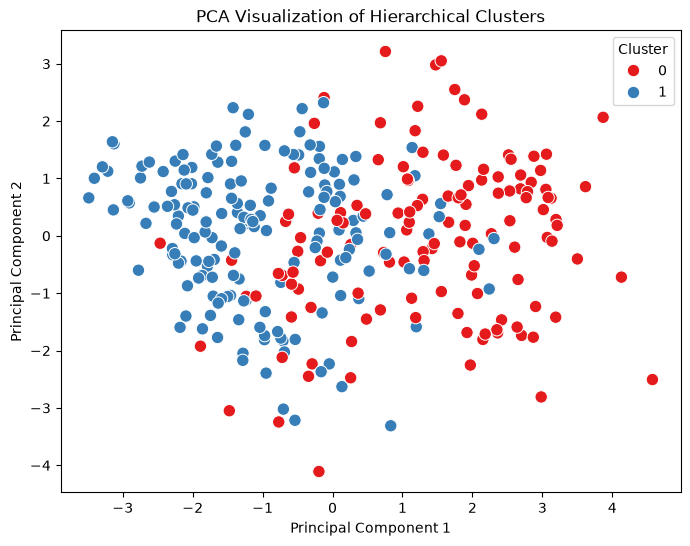

In [204]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=hierarchical_pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.title(
    'PCA Visualization of Hierarchical Clusters'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

plt.show()

In [205]:
clustering_comparison = pd.DataFrame({
    'Method': [
        'K-Means',
        'Hierarchical Clustering'
    ],
    'Number of Clusters': [
        len(np.unique(kmeans_labels)),
        len(np.unique(hierarchical_labels))
    ],
    'Silhouette Score': [
        kmeans_silhouette,
        hierarchical_silhouette
    ],
    'Davies-Bouldin Index': [
        kmeans_db,
        hierarchical_db
    ],
    'Calinski-Harabasz Score': [
        kmeans_ch,
        hierarchical_ch
    ]
})

clustering_comparison.round(4)

,Method,Number of Clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,K-Means,2,0.1751,2.0792,61.6656
1,Hierarchical Clustering,2,0.1317,2.6028,41.5964


In [206]:
from sklearn.metrics import adjusted_rand_score

kmeans_hierarchical_ari = adjusted_rand_score(
    kmeans_labels,
    hierarchical_labels
)

print(
    "Adjusted Rand Index between K-Means and Hierarchical Clustering:",
    round(kmeans_hierarchical_ari, 4)
)

Adjusted Rand Index between K-Means and Hierarchical Clustering: 0.3688


### 8.4 Comparison with Known Heart Disease Labels

In [207]:
kmeans_target_table = pd.crosstab(
    kmeans_labels,
    df['target'],
    rownames=['K-Means Cluster'],
    colnames=['Heart Disease Status']
)

kmeans_target_table

Heart Disease Status,0,1
K-Means Cluster,,
0,147,37
1,13,100


In [208]:
kmeans_disease_rate = pd.crosstab(
    kmeans_labels,
    df['target'],
    normalize='index'
) * 100

kmeans_disease_rate.columns = [
    'No Heart Disease (%)',
    'Heart Disease (%)'
]

kmeans_disease_rate.round(2)

,No Heart Disease (%),Heart Disease (%)
row_0,,
0,79.89,20.11
1,11.50,88.50


In [209]:
hierarchical_target_table = pd.crosstab(
    hierarchical_labels,
    df['target'],
    rownames=['Hierarchical Cluster'],
    colnames=['Heart Disease Status']
)

hierarchical_target_table

Heart Disease Status,0,1
Hierarchical Cluster,,
0,43,86
1,117,51


In [210]:
hierarchical_disease_rate = pd.crosstab(
    hierarchical_labels,
    df['target'],
    normalize='index'
) * 100

hierarchical_disease_rate.columns = [
    'No Heart Disease (%)',
    'Heart Disease (%)'
]

hierarchical_disease_rate.round(2)

,No Heart Disease (%),Heart Disease (%)
row_0,,
0,33.33,66.67
1,69.64,30.36


In [211]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score
)

kmeans_target_ari = adjusted_rand_score(
    df['target'],
    kmeans_labels
)

kmeans_target_nmi = normalized_mutual_info_score(
    df['target'],
    kmeans_labels
)

hierarchical_target_ari = adjusted_rand_score(
    df['target'],
    hierarchical_labels
)

hierarchical_target_nmi = normalized_mutual_info_score(
    df['target'],
    hierarchical_labels
)

print("K-Means vs Target")
print("-----------------")
print("Adjusted Rand Index:", round(kmeans_target_ari, 4))
print("Normalized Mutual Information:", round(kmeans_target_nmi, 4))

print("\nHierarchical Clustering vs Target")
print("---------------------------------")
print("Adjusted Rand Index:", round(hierarchical_target_ari, 4))
print("Normalized Mutual Information:", round(hierarchical_target_nmi, 4))

K-Means vs Target
-----------------
Adjusted Rand Index: 0.438
Normalized Mutual Information: 0.3594

Hierarchical Clustering vs Target
---------------------------------
Adjusted Rand Index: 0.1317
Normalized Mutual Information: 0.0967


### 8.5 Cluster Profile Analysis

In [212]:
kmeans_profile = cluster_results_df.groupby(
    'kmeans_cluster'
)[X_cluster.columns].mean()

kmeans_profile.round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
kmeans_cluster,,,,,,,,,,,,,
0,52.20,0.59,2.78,129.67,242.82,0.12,0.86,159.88,0.11,0.54,1.38,0.32,3.85
1,58.36,0.81,3.77,134.99,254.73,0.19,1.21,132.86,0.67,1.89,1.96,1.27,6.16


In [213]:
kmeans_profile_with_target = kmeans_profile.copy()

kmeans_profile_with_target[
    'Heart Disease Rate'
] = cluster_results_df.groupby(
    'kmeans_cluster'
)['target'].mean()

kmeans_profile_with_target.round(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Heart Disease Rate
kmeans_cluster,,,,,,,,,,,,,,
0,52.196,0.592,2.783,129.668,242.815,0.120,0.864,159.880,0.114,0.543,1.380,0.315,3.853,0.201
1,58.363,0.814,3.770,134.991,254.735,0.186,1.212,132.858,0.673,1.890,1.965,1.265,6.159,0.885


In [214]:
scaled_profile_df = pd.DataFrame(
    X_cluster_scaled,
    columns=X_cluster.columns
)

scaled_profile_df[
    'kmeans_cluster'
] = kmeans_labels

scaled_kmeans_profile = scaled_profile_df.groupby(
    'kmeans_cluster'
).mean()

scaled_kmeans_profile.round(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
kmeans_cluster,,,,,,,,,,,,,
0,-0.260,-0.180,-0.390,-0.114,-0.087,-0.072,-0.133,0.449,-0.453,-0.440,-0.360,-0.386,-0.453
1,0.423,0.294,0.635,0.186,0.142,0.117,0.217,-0.731,0.738,0.717,0.586,0.628,0.738


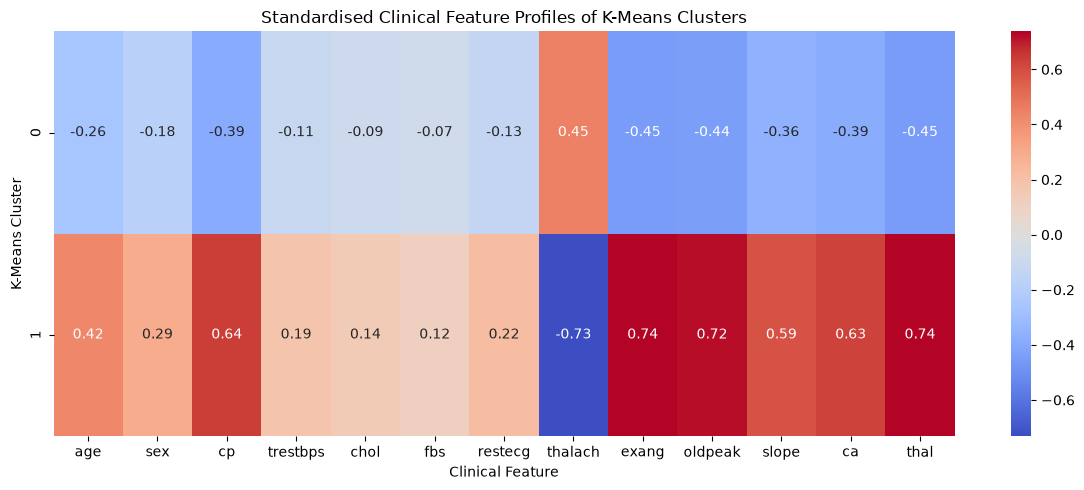

In [215]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    scaled_kmeans_profile,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Standardised Clinical Feature Profiles of K-Means Clusters'
)

plt.xlabel('Clinical Feature')
plt.ylabel('K-Means Cluster')
plt.tight_layout()

plt.show()

In [216]:
cluster_feature_difference = (
    scaled_kmeans_profile.loc[1]
    - scaled_kmeans_profile.loc[0]
).abs().sort_values(
    ascending=False
)

cluster_feature_difference.to_frame(
    name='Absolute Standardised Difference'
).round(3)

,Absolute Standardised Difference
thal,1.192
exang,1.191
thalach,1.180
oldpeak,1.157
cp,1.025
ca,1.014
slope,0.947
age,0.683
sex,0.474
restecg,0.351


### 8.6 Clustering Findings

K-Means produced the stronger clustering solution compared with Hierarchical Clustering. For K-Means, the Silhouette Score was 0.1751, the Davies-Bouldin Index was 2.0792, and the Calinski-Harabasz Score was 61.6656. These values were better than those obtained from Hierarchical Clustering, which achieved a Silhouette Score of 0.1317, a Davies-Bouldin Index of 2.6028, and a Calinski-Harabasz Score of 41.5964.

Although the overall silhouette values were relatively low, K-Means identified two clinically meaningful patient groups. Cluster 0 contained 184 patients and had a heart disease rate of 20.1%, whereas Cluster 1 contained 113 patients and had a heart disease rate of 88.5%. The K-Means clustering showed moderate agreement with the known heart disease labels, with an Adjusted Rand Index of 0.4380 and a Normalised Mutual Information score of 0.3594.

The high-risk cluster was characterised by higher values of thal, exercise-induced angina, oldpeak, chest pain type, number of major vessels and slope, together with lower maximum heart rate. The largest standardised differences between the two clusters were observed for thal, exercise-induced angina, maximum heart rate, oldpeak and chest pain type.

The first two principal components explained 36.04% of the total variance. Therefore, the PCA plots provided a useful visual summary but did not represent the full high-dimensional structure of the data. Overall, the clustering results suggested that the clinical features contained natural patient groupings associated with heart disease status, although the separation between clusters was not strong enough for clustering to replace supervised classification.

## 9. Discussion

### 9.1 Classification Model Performance

Five supervised classification models were evaluated using both a held-out test set and stratified 10-fold cross-validation. The models demonstrated different strengths across accuracy, sensitivity, specificity, F1-score and ROC-AUC. This shows that model performance should not be judged using accuracy alone, particularly in a medical classification task where false-negative and false-positive predictions have different practical consequences.

Support Vector Machine achieved the highest mean cross-validation accuracy of 0.8318 and the highest test ROC-AUC of 0.9529. Its test accuracy was 0.8667, with a sensitivity of 0.8286 and a specificity of 0.9000. These results indicate that the tuned RBF-kernel SVM provided strong overall discrimination and a relatively balanced ability to identify both patients with and without heart disease.

Naive Bayes achieved a very similar mean cross-validation accuracy of 0.8317 and the highest test accuracy of 0.8800 among the evaluated models. Its performance was strong despite the simplifying assumption that predictor variables are conditionally independent. However, the clinical variables in this dataset are likely to be related, meaning that the assumptions of Naive Bayes may not fully reflect the underlying clinical relationships.

Logistic Regression produced a test accuracy of 0.8533 and an ROC-AUC of 0.9471. Although its predictive performance was slightly below that of SVM on several measures, it had the lowest cross-validation standard deviation of 0.0471. This suggests that Logistic Regression was the most stable model across different data partitions. Its coefficients also offer greater interpretability than the nonlinear SVM model, which may make it preferable when transparent clinical reasoning is important.

The final KNN model achieved a test accuracy of 0.8667. Although k=3 produced the highest result in the initial single test-set comparison, 10-fold cross-validation selected k=20 as the more stable choice. This difference demonstrates why hyperparameters should be selected using training-data cross-validation rather than repeated inspection of the test set. KNN remained sensitive to feature scaling and the selected number of neighbours.

The tuned Decision Tree achieved a lower test accuracy of 0.7733 and a lower ROC-AUC of 0.7757. It produced a high specificity of 0.9250 but a sensitivity of only 0.6000. This indicates that the model was effective at correctly identifying patients without heart disease, but it failed to detect a relatively large proportion of patients with the disease.

The Decision Tree nevertheless provided useful interpretability through explicit decision rules and feature-importance estimates. Its weaker predictive performance may reflect the instability of individual trees and the limited sample size. More advanced tree-based ensemble methods, such as Random Forest or gradient boosting, may improve performance by combining multiple trees and reducing variance.

Overall, Support Vector Machine was selected as the strongest general-purpose classification model because it combined the highest ROC-AUC with the highest mean cross-validation accuracy. However, the difference between SVM and Naive Bayes in cross-validation accuracy was negligible. Logistic Regression also remained a strong alternative because of its stability and interpretability. Therefore, the most appropriate model depends on whether the priority is maximum discrimination, stable performance or transparent clinical interpretation.

### 9.2 Interpretation of Clustering Results

K-Means produced a stronger clustering solution than Hierarchical Clustering across all three internal validation measures. K-Means achieved a Silhouette Score of 0.1751, a Davies-Bouldin Index of 2.0792 and a Calinski-Harabasz Score of 61.6656. In comparison, Hierarchical Clustering achieved a lower Silhouette Score of 0.1317, a higher Davies-Bouldin Index of 2.6028 and a lower Calinski-Harabasz Score of 41.5964. These results indicate that the K-Means clusters were more compact and better separated than the hierarchical clusters.

However, the silhouette values for both clustering methods were relatively low. This suggests that the patients did not form clearly separated natural groups in the full 13-dimensional feature space. Heart disease risk is influenced by several interacting clinical factors, many of which vary continuously rather than forming completely distinct categories. Therefore, overlap between clusters was expected.

The PCA visualisations showed an apparent separation between patient groups, particularly along the first principal component. Nevertheless, the first two principal components explained only 36.04% of the total variance. Therefore, the two-dimensional plots represented only part of the original information and may have made the separation appear clearer than it was in the full feature space.

K-Means showed a stronger relationship with the known heart disease labels than Hierarchical Clustering. In the K-Means solution, Cluster 0 had a heart disease rate of 20.1%, whereas Cluster 1 had a rate of 88.5%. The Adjusted Rand Index of 0.4380 and Normalised Mutual Information score of 0.3594 indicated moderate agreement between the K-Means grouping and the known target labels.

In contrast, Hierarchical Clustering produced weaker agreement with the target labels, with an Adjusted Rand Index of 0.1317 and a Normalised Mutual Information score of 0.0967. This suggests that its grouping structure was less closely related to heart disease status.

The high-risk K-Means cluster was characterised by higher values of thal, exercise-induced angina, oldpeak, chest pain type, number of major vessels and slope, together with lower maximum heart rate. These variables showed the largest standardised differences between the two clusters and were consistent with the strong separation observed in disease rates.

Despite this clinically meaningful grouping, clustering should not be treated as a diagnostic classifier. The cluster identifiers were generated without using the target label and had no fixed clinical meaning. Clustering was therefore useful for exploratory patient segmentation, whereas supervised classification was more appropriate for predicting heart disease status in unseen patients.

### 9.3 Limitations and Future Improvements

The first limitation of this study was the relatively small sample size. After removing records containing missing values, 297 patient records remained for analysis. Although stratified sampling and cross-validation were used to improve the reliability of the evaluation, results obtained from a small dataset may still vary across different data partitions.

In addition, the analysis used only the Cleveland subset of the UCI Heart Disease dataset. The model performance may therefore reflect the characteristics of this specific patient population and may not generalise directly to patients from other hospitals, regions or demographic groups.

Six records containing missing values in the ca and thal variables were removed. This approach was reasonable because the number of affected records was small, but complete-case deletion may still introduce bias if the missing values were not random. Future studies could compare deletion with more advanced imputation methods, such as multiple imputation or model-based imputation.

Several variables, including chest pain type, resting electrocardiographic results, slope and thal, were represented using numerical codes but conceptually functioned as categorical or ordinal variables. In the present analysis, all features were treated as numerical inputs. This simplified the modelling process but may not fully represent the meaning of these variables.

Future work could use a ColumnTransformer to standardise continuous variables while applying appropriate encoding to categorical variables. This would provide a more rigorous preprocessing pipeline and may improve model performance.

The study used a single held-out test set together with stratified 10-fold cross-validation. Cross-validation provided a more stable estimate of average performance, but the final test metrics were still based on one particular train-test split. Nested cross-validation could be used in future work to separate hyperparameter tuning from performance estimation more strictly.

The main hyperparameters of KNN, Decision Tree and SVM were tuned, whereas Naive Bayes and Logistic Regression were evaluated using relatively standard configurations. A broader and more systematic search could be applied to all models.

Future classification work could evaluate ensemble methods such as Random Forest, Gradient Boosting and AdaBoost. These methods may improve predictive performance by combining multiple weak or unstable learners. Feature selection and regularisation could also be investigated to reduce redundant predictors and improve model interpretability.

For clustering, the relatively low silhouette scores indicated weak natural separation in the full feature space. Future analysis could compare additional clustering algorithms such as DBSCAN or Gaussian Mixture Models. Alternative distance measures, dimensionality-reduction techniques and clustering methods designed for mixed numerical and categorical data could also be considered.

Finally, the models should be validated using an independent external dataset before being considered for practical clinical use. The results of this study should be interpreted as an educational machine-learning analysis rather than a clinical diagnostic system.

## 10. Conclusion

This study investigated whether clinical variables from the Cleveland Heart Disease dataset could be used to predict heart disease status and identify meaningful patient groups. After data cleaning, 297 complete patient records and 13 predictor variables were retained. Exploratory data analysis showed that several clinical characteristics, including chest pain type, maximum heart rate, exercise-induced angina, oldpeak, number of major vessels and thal, differed noticeably between patients with and without heart disease.

Five supervised machine-learning models were developed and evaluated: K-Nearest Neighbours, Naive Bayes, Logistic Regression, Decision Tree and Support Vector Machine. Support Vector Machine provided the strongest overall discrimination, achieving a test accuracy of 0.8667, a sensitivity of 0.8286, a specificity of 0.9000 and the highest ROC-AUC of 0.9529. It also achieved the highest mean 10-fold cross-validation accuracy of 0.8318, although this was almost identical to the Naive Bayes result of 0.8317. Naive Bayes achieved the highest test accuracy of 0.8800, while Logistic Regression provided strong performance together with the most stable cross-validation results.

Decision Tree produced the weakest overall predictive performance, particularly because its sensitivity was only 0.6000. Nevertheless, it remained useful for interpreting explicit decision rules. These results demonstrate that model selection should consider sensitivity, specificity, F1-score, ROC-AUC, cross-validation stability and interpretability rather than accuracy alone.

Unsupervised analysis was also conducted using K-Means and Hierarchical Clustering. K-Means produced the stronger clustering solution, with a Silhouette Score of 0.1751, a Davies-Bouldin Index of 2.0792 and a Calinski-Harabasz Score of 61.6656. It identified a lower-risk cluster with a heart disease rate of 20.1% and a higher-risk cluster with a heart disease rate of 88.5%. The high-risk cluster was characterised particularly by higher thal, exercise-induced angina, oldpeak, chest pain type and number of major vessels, together with lower maximum heart rate.

However, the relatively low silhouette scores indicated that the patients did not form strongly separated natural groups in the full feature space. Therefore, clustering was useful for exploratory patient segmentation but was less appropriate than supervised classification for predicting the heart disease status of individual patients.

Overall, the results show that the selected clinical variables contain useful information for heart disease prediction. Support Vector Machine was the strongest general-purpose predictive model, while Logistic Regression remained a valuable alternative when stability and interpretability were prioritised. Further work should validate these findings using larger and independent datasets, more rigorous preprocessing pipelines and additional ensemble-learning methods.

## 11. References

1. Janosi, A., Steinbrunn, W., Pfisterer, M. and Detrano, R. (1988) *Heart Disease*. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X

2. Pedregosa, F. et al. (2011) ‘Scikit-learn: Machine Learning in Python’, *Journal of Machine Learning Research*, 12, pp. 2825–2830.

3. McKinney, W. (2010) ‘Data structures for statistical computing in Python’, in *Proceedings of the 9th Python in Science Conference*, pp. 56–61.

4. Harris, C.R. et al. (2020) ‘Array programming with NumPy’, *Nature*, 585, pp. 357–362.

5. Hunter, J.D. (2007) ‘Matplotlib: A 2D graphics environment’, *Computing in Science and Engineering*, 9(3), pp. 90–95.

6. Waskom, M.L. (2021) ‘Seaborn: Statistical data visualization’, *Journal of Open Source Software*, 6(60), Article 3021.

7. Cover, T.M. and Hart, P.E. (1967) ‘Nearest neighbor pattern classification’, *IEEE Transactions on Information Theory*, 13(1), pp. 21–27.

8. Cortes, C. and Vapnik, V. (1995) ‘Support-vector networks’, *Machine Learning*, 20, pp. 273–297.

9. Hosmer, D.W., Lemeshow, S. and Sturdivant, R.X. (2013) *Applied Logistic Regression*. 3rd edn. Hoboken, NJ: Wiley.

10. Quinlan, J.R. (1986) ‘Induction of decision trees’, *Machine Learning*, 1, pp. 81–106.

11. Fawcett, T. (2006) ‘An introduction to ROC analysis’, *Pattern Recognition Letters*, 27(8), pp. 861–874.

12. MacQueen, J. (1967) ‘Some methods for classification and analysis of multivariate observations’, in *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability*, pp. 281–297.

13. Murtagh, F. and Legendre, P. (2014) ‘Ward’s hierarchical agglomerative clustering method: Which algorithms implement Ward’s criterion?’, *Journal of Classification*, 31, pp. 274–295.

14. Rousseeuw, P.J. (1987) ‘Silhouettes: A graphical aid to the interpretation and validation of cluster analysis’, *Journal of Computational and Applied Mathematics*, 20, pp. 53–65.

15. Davies, D.L. and Bouldin, D.W. (1979) ‘A cluster separation measure’, *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-1(2), pp. 224–227.

16. Calinski, T. and Harabasz, J. (1974) ‘A dendrite method for cluster analysis’, *Communications in Statistics*, 3(1), pp. 1–27.

17. Jolliffe, I.T. and Cadima, J. (2016) ‘Principal component analysis: A review and recent developments’, *Philosophical Transactions of the Royal Society A*, 374, Article 20150202.

18. Zheng, H. and Fu, J. (2026) *Classification and Model Evaluation*. Machine Learning, Sichuan University. Unpublished lecture slides.

19. Zheng, H. and Fu, J. (2026) *Clustering Analysis*. Machine Learning, Sichuan University. Unpublished lecture slides.

20. Zheng, H. and Fu, J. (2026) *Laboratory 2: Classification Using K-Nearest Neighbours*. Machine Learning, Sichuan University. Unpublished laboratory material.